In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import calendar
import duckdb


warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Chart style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print("Libraries loaded successfully")

Libraries loaded successfully


# Chicago Taxi Data Analysis — 2020

**Author:** Laurentiu Rapiteanu  
**Dataset:** Chicago Taxi Trips 2020 (2,016,157 rows)  
**Tools:** Python, pandas, matplotlib, seaborn

---

## Overview

This notebook analyses the Chicago government taxi dataset for 2020. It covers three tasks:

1. **Data Model** — proposed normalised structure for the flat CSV data
2. **Data Analysis** — five insights extracted from 2 million trip records
3. **CEO KPI** — a daily metric designed for executive decision-making

The year 2020 is particularly interesting for taxi data due to the impact of COVID-19 on urban transportation demand.

In [2]:
# Load and Explore the Raw Data

# Load CSV with optimised dtypes to reduce memory usage
df = pd.read_csv(
    'chicago_taxi_2020.csv',
    dtype={
        'unique_key': 'str',
        'taxi_id': 'str',
        'fare': 'float32',
        'tips': 'float32',
        'tolls': 'float32',
        'extras': 'float32',
        'payment_type': 'category',
        'company': 'category',
        'trip_miles': 'float32',
        'trip_seconds': 'float32'
    }
)

print(f"Dataset loaded successfully")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset loaded successfully
Rows: 2,016,157
Columns: 11
Memory usage: 699.9 MB


# Preview the first 5 rows
df.head()

In [3]:
# Column names and data types
print("Column types:")
print(df.dtypes)

Column types:
unique_key                   str
taxi_id                      str
trip_start_timestamp         str
fare                     float32
tips                     float32
tolls                    float32
extras                   float32
payment_type            category
company                 category
trip_miles               float32
trip_seconds             float32
dtype: object


In [4]:
# Missing values per column
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing values:
              Missing Count  Missing %
taxi_id                 129       0.01
fare                    140       0.01
tips                    140       0.01
tolls                   140       0.01
extras                  140       0.01
trip_miles               15       0.00
trip_seconds            491       0.02


In [5]:
# Basic statistics for numeric columns
df.describe()

,fare,tips,tolls,extras,trip_miles,trip_seconds
count,2016017.00,2016017.00,2016017.00,2016017.00,2016142.00,2015666.00
mean,14.04,1.50,0.00,1.01,3.21,827.98
std,49.99,2.77,0.09,25.03,5.73,1487.11
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.75,0.00,0.00,0.00,0.20,344.00
50%,8.00,0.00,0.00,0.00,1.10,555.00
75%,15.25,2.00,0.00,1.00,3.10,1020.00
max,9004.25,300.00,90.00,9900.66,993.60,85867.00


## Section 1 — Data Exploration

The dataset contains **2,016,157 taxi trips** recorded in Chicago during 2020, across 11 columns.

### Column Descriptions

| Column | Type | Description |
|---|---|---|
| unique_key | string | Unique identifier for each trip |
| taxi_id | string | Anonymised driver/vehicle identifier |
| trip_start_timestamp | string | When the trip started (UTC) |
| fare | float | Base fare charged ($) |
| tips | float | Tip amount ($) |
| tolls | float | Toll charges ($) |
| extras | float | Additional surcharges ($) |
| payment_type | category | Cash, Credit Card, Mobile, etc. |
| company | category | Taxi company name |
| trip_miles | float | Trip distance in miles |
| trip_seconds | float | Trip duration in seconds |

### Data Quality Findings

- Missing values are negligible — less than 0.02% across all columns. These rows will be dropped.
- Outliers are present — maximum fare of $9,004 and maximum trip distance of 993 miles are clearly data errors and will be removed before analysis.
- Trips with zero miles and zero seconds exist — these are ghost trips and will be removed.
- The dataset covers the full year 2020 — including the COVID-19 lockdown period starting March 2020.
    

## Section 2 — Data Model

### Design Approach

I designed the data model as a **lightweight star schema** centered on `fact_trips`, because the natural grain of the dataset is one row per taxi trip. The trip is the core business event in this dataset, containing the main measurable values such as fare, tips, tolls, extras, distance, and duration.

The key modelling principle applied here is:

> **Model around the actual business event.**

In this dataset, the business event is not a customer, not a company, and not a day. It is a taxi trip happening at a point in time. This is why `fact_trips` is the correct centre of the model. If the model had instead been built around companies or daily summaries, important operational detail would have been lost and analytical flexibility reduced.

A star schema is appropriate here because this dataset is intended for analytical querying and aggregation, not for high-frequency transactional updates. The goal is to support reporting, KPI generation, and dashboarding in a simple and efficient way, while keeping the solution aligned with an MVP approach.

---

### Star Schema Structure

**Fact Table**

`fact_trips` contains one row per taxi trip. It stores all measurable trip facts together with foreign keys linking to the dimension tables.

**Dimension Tables**

- `dim_date` stores calendar attributes such as day of week, month, year, and `is_weekend`. The `date_key` is an integer derived from the calendar date (for example, `20200115` for 15 January 2020), allowing trips to be joined to date attributes without recalculating them at query time.
- `dim_company` stores one row per taxi company, eliminating repeated company names across millions of trip rows.
- `dim_payment_type` stores one row per payment method, normalising raw payment strings into a consistent analytical dimension.
- `dim_taxi` stores one row per taxi. At present it contains only `taxi_id`, since the source dataset does not include additional driver or vehicle metadata. It is retained as a dimension for extensibility, so that future taxi or driver attributes can be added without restructuring the fact table.

---

### Derived Metrics in fact_trips

The following metrics were calculated during feature engineering and stored directly in the fact table to support efficient reporting and KPI calculation:

| Column | Formula | Purpose |
|---|---|---|
| `total_revenue` | fare + tips + tolls + extras | Full trip value |
| `trip_minutes` | trip_seconds / 60 | Readable duration |
| `revenue_per_mile` | total_revenue / trip_miles | Trip efficiency by distance |
| `revenue_per_minute` | total_revenue / trip_minutes | Trip efficiency by time |
| `tip_rate` | tips / fare | Tipping behaviour |

`revenue_per_mile` and `revenue_per_minute` are based on total revenue rather than fare alone, because tips, tolls, and extras all contribute to the economic value of a trip and are therefore more meaningful for management-level analysis.

---

### Why Star Schema Over Other Models

A flat table would be sufficient for initial exploration, but not ideal for repeated analytical querying because descriptive values such as company names and payment types are repeated in every row, and time-based attributes would need to be recalculated repeatedly.

A fully normalised 3NF relational model would be better suited to a transactional system with frequent inserts and updates, but this dataset is read-heavy and analytical in nature. In this context, a star schema is the better design choice because it keeps queries simple, supports aggregation efficiently, and provides a cleaner foundation for dashboards and KPI reporting.

| Model | Why Not Chosen |
|---|---|
| Flat CSV | Redundant descriptive values in every row, no referential integrity |
| 3NF Relational | Optimised for writes not reads — better for transactional systems |
| Document (MongoDB) | Flexible schema not needed — data is highly structured |
| Graph | Relationships are simple hierarchies, not complex networks |
| **Star Schema** | Optimised for analytical queries, supports KPI and dashboard generation |

---

### Production Implementation

In a production environment, this model could be implemented in **AWS Redshift** for scalable analytical querying, or stored as Parquet files in **Amazon S3** and queried using **AWS Athena** for a simpler serverless approach. For this case study, I used **pandas** for data loading and feature engineering, and **DuckDB** for analytical SQL queries. This kept the solution lightweight, easy to run locally, and aligned with the MVP nature of the task.

## Section 3 — Data Cleaning & Feature Engineering

Before analysing the data we address three issues found during exploration:
- **Missing values** — dropped (less than 0.02% of data, negligible loss)
- **Ghost trips** — trips with zero miles AND zero seconds removed
- **Extreme outliers** — fares over $500, trips over 100 miles or 4 hours removed

We also derive new columns needed for analysis:
- `total_revenue` — sum of all charges per trip
- `trip_minutes` — duration in minutes (more readable than seconds)
- `fare_per_mile` — revenue efficiency per mile
- `tip_rate` — tip as a percentage of fare
- `hour`, `day_of_week`, `month`, `month_name` — extracted from timestamp

In [6]:
# Section 3 — Data Cleaning & Feature Engineering

original_count = len(df)
print(f"Starting rows: {original_count:,}")

# --- Step 1: Drop missing values ---
df = df.dropna()
after_dropna = len(df)
print(f"After dropping missing values: {after_dropna:,} (removed {original_count - after_dropna:,} rows)")

# --- Step 2: Remove ghost trips ---
# Trips with both zero miles AND zero seconds are recording errors
df = df[~((df['trip_miles'] == 0) & (df['trip_seconds'] == 0))]
after_ghost = len(df)
print(f"After removing ghost trips: {after_ghost:,} (removed {after_dropna - after_ghost:,} rows)")

# --- Step 3: Remove extreme outliers ---
df = df[df['fare'] <= 500]
df = df[df['trip_miles'] <= 100]
df = df[df['trip_seconds'] <= 14400]
df = df[df['extras'] <= 100]
after_outliers = len(df)
print(f"After removing outliers: {after_outliers:,} (removed {after_ghost - after_outliers:,} rows)")

# --- Step 4: Parse timestamp ---
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], utc=True)

# --- Step 5: Feature engineering ---
df['total_revenue']  = df['fare'] + df['tips'] + df['tolls'] + df['extras']
df['trip_minutes']   = df['trip_seconds'] / 60
df['fare_per_mile']  = df['fare'] / df['trip_miles'].replace(0, float('nan'))
df['tip_rate']       = df['tips'] / df['fare'].replace(0, float('nan'))
df['hour']           = df['trip_start_timestamp'].dt.hour
df['day_of_week']    = df['trip_start_timestamp'].dt.day_name()
df['month']          = df['trip_start_timestamp'].dt.month
df['month_name']     = df['trip_start_timestamp'].dt.strftime('%b')

total_removed = original_count - len(df)
pct_removed = (total_removed / original_count * 100)

print(f"\nCleaning complete:")
print(f"Original rows:  {original_count:,}")
print(f"Clean rows:     {len(df):,}")
print(f"Rows removed:   {total_removed:,} ({pct_removed:.2f}% of data)")
print(f"\nNew columns added: total_revenue, trip_minutes, fare_per_mile, tip_rate, hour, day_of_week, month, month_name")

Starting rows: 2,016,157
After dropping missing values: 2,015,388 (removed 769 rows)
After removing ghost trips: 1,963,024 (removed 52,364 rows)
After removing outliers: 1,961,129 (removed 1,895 rows)

Cleaning complete:
Original rows:  2,016,157
Clean rows:     1,961,129
Rows removed:   55,028 (2.73% of data)

New columns added: total_revenue, trip_minutes, fare_per_mile, tip_rate, hour, day_of_week, month, month_name


In [7]:
# Investigate exactly what data we have

# How many months are in the dataset
print("=== MONTHS IN DATASET ===")
month_summary = df.groupby(['month', 'month_name']).agg(
    trip_count=('unique_key', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_fare=('fare', 'mean')
).reset_index()
month_summary['total_revenue_M'] = month_summary['total_revenue'] / 1_000_000
print(month_summary[['month_name', 'trip_count', 'total_revenue_M', 'avg_fare']].to_string(index=False))

# Date range
print("\n=== DATE RANGE ===")
print(f"Earliest trip: {df['trip_start_timestamp'].min()}")
print(f"Latest trip:   {df['trip_start_timestamp'].max()}")

# July specifically
print("\n=== JULY DETAIL ===")
july = df[df['month'] == 7]
print(f"July trips: {len(july):,}")
if len(july) > 0:
    print(july['trip_start_timestamp'].describe())

=== MONTHS IN DATASET ===
month_name  trip_count  total_revenue_M  avg_fare
       Jan      686758            11.15     13.62
       Feb      725211            11.82     13.66
       Mar      368562             5.82     13.51
       Apr       45936             0.75     15.82
       May       57989             0.96     15.81
       Jun       76668             1.30     15.86
       Jul           5             0.00     12.25

=== DATE RANGE ===
Earliest trip: 2020-01-02 00:00:00+00:00
Latest trip:   2020-07-01 00:00:00+00:00

=== JULY DETAIL ===
July trips: 5
count                            5
mean     2020-07-01 00:00:00+00:00
min      2020-07-01 00:00:00+00:00
25%      2020-07-01 00:00:00+00:00
50%      2020-07-01 00:00:00+00:00
75%      2020-07-01 00:00:00+00:00
max      2020-07-01 00:00:00+00:00
Name: trip_start_timestamp, dtype: object


In [8]:
# Display the 5 July trips
july_trips = df[df['month'] == 7]
print(f"July trips: {len(july_trips)}")
print("\nFull details:")
july_trips

July trips: 5

Full details:


,unique_key,taxi_id,trip_start_timestamp,fare,tips,tolls,extras,payment_type,company,trip_miles,trip_seconds,total_revenue,trip_minutes,fare_per_mile,tip_rate,hour,day_of_week,month,month_name
103315,174f15f28fe428ccfba2f4b8cfba8c9f7715d83d,e93472aad9e00c0a523e1a861ae897303548d713ba63d3...,2020-07-01 00:00:00+00:00,6.75,0.00,0.00,0.00,Cash,Flash Cab,1.55,190.00,6.75,3.17,4.35,0.00,0,Wednesday,7,Jul
193391,5d185441d8e723c67c57ef3a3792be80626e7a4e,96a96f52dbf30dc4376ecdb36a6bb955e242a3e2a281c1...,2020-07-01 00:00:00+00:00,6.50,0.00,0.00,0.00,Cash,Flash Cab,0.76,525.00,6.50,8.75,8.55,0.00,0,Wednesday,7,Jul
1410026,11e4a130c6a7f8dbad6e27dde838d3c74ccc2b55,223702c6155649517dcb9f4860ae0fa2669903bbe7d54f...,2020-07-01 00:00:00+00:00,24.25,0.00,0.00,0.00,Unknown,Taxi Affiliation Services,0.50,900.00,24.25,15.00,48.50,0.00,0,Wednesday,7,Jul
1442154,127c17945fdc2d722d8c66be660e6b61db93e051,3497d2b935bf09123c257fd1ff03b4ca266e067fac8e97...,2020-07-01 00:00:00+00:00,18.50,0.00,0.00,1.50,Cash,Taxi Affiliation Services,0.30,1080.00,20.00,18.00,61.67,0.00,0,Wednesday,7,Jul
1632368,997f72d72b67c5444420e9ba30aa538d519a67ee,a9c03c904e899fd10c47c237b5352239f5ce6e181227e7...,2020-07-01 00:00:00+00:00,5.25,0.00,0.00,1.00,Cash,Taxi Affiliation Services,0.80,240.00,6.25,4.00,6.56,0.00,0,Wednesday,7,Jul


In [9]:
import duckdb

# Test DuckDB can query our cleaned pandas DataFrame directly
test = duckdb.query("""
    SELECT 
        month,
        month_name,
        COUNT(*) as trip_count,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(AVG(fare), 2) as avg_fare
    FROM df
    GROUP BY month, month_name
    ORDER BY month
""").df()

print("DuckDB connected successfully")
print(test)

DuckDB connected successfully
   month month_name  trip_count  total_revenue  avg_fare
0      1        Jan      686758    11152413.88     13.62
1      2        Feb      725211    11815591.08     13.66
2      3        Mar      368562     5816614.12     13.51
3      4        Apr       45936      754107.34     15.82
4      5        May       57989      960988.33     15.81
5      6        Jun       76668     1301635.52     15.86
6      7        Jul           5          63.75     12.25


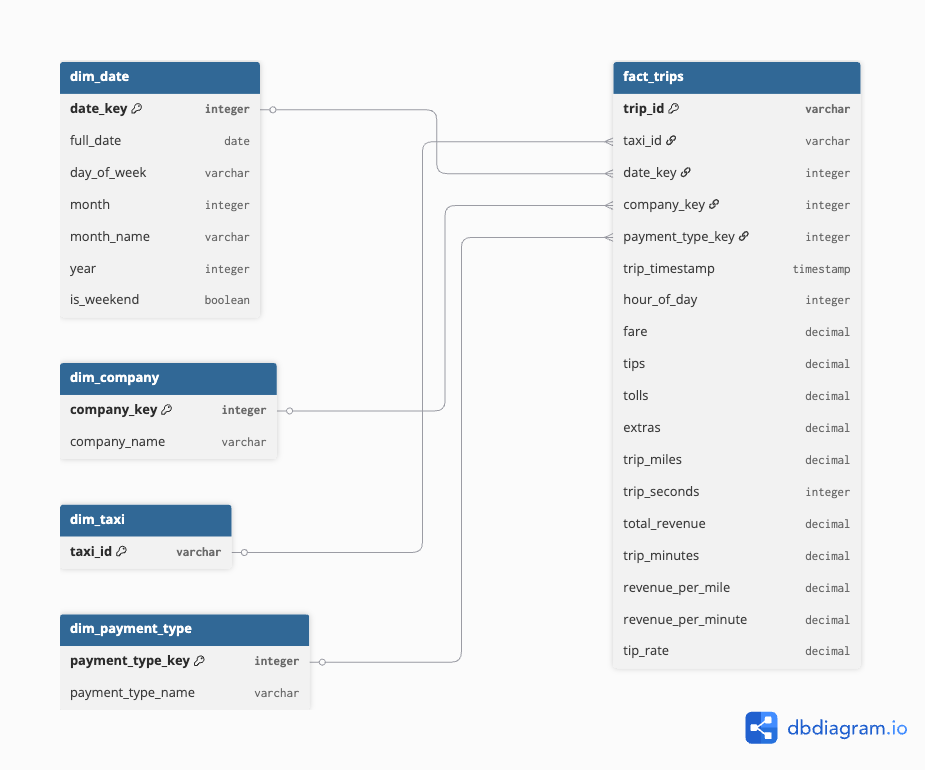

In [10]:
from IPython.display import Image
Image('DataModel.png')

In [11]:
# Recalculate as revenue (total) not just fare
df['revenue_per_mile'] = df['total_revenue'] / df['trip_miles'].replace(0, float('nan'))
df['revenue_per_minute'] = df['total_revenue'] / df['trip_minutes'].replace(0, float('nan'))

# Drop the old incorrectly named columns if they exist
df = df.drop(columns=['fare_per_mile', 'fare_per_minute'], errors='ignore')

print("Revenue per mile and per minute recalculated correctly")
print(f"Sample revenue_per_mile: ${df['revenue_per_mile'].mean():.2f}")
print(f"Sample revenue_per_minute: ${df['revenue_per_minute'].mean():.2f}")

Revenue per mile and per minute recalculated correctly
Sample revenue_per_mile: $14.68
Sample revenue_per_minute: $1.69


In [12]:
verify = duckdb.query("""
    SELECT 
        ROUND(AVG(fare), 2) as avg_fare,
        ROUND(AVG(total_revenue), 2) as avg_total_revenue,
        ROUND(AVG(trip_miles), 2) as avg_miles,
        ROUND(AVG(trip_minutes), 2) as avg_minutes,
        ROUND(AVG(total_revenue) / AVG(trip_miles), 2) as revenue_per_mile_correct,
        ROUND(AVG(total_revenue) / AVG(trip_minutes), 2) as revenue_per_min_correct,
        ROUND(AVG(revenue_per_mile), 2) as revenue_per_mile_mean,
        ROUND(AVG(revenue_per_minute), 2) as revenue_per_min_mean
    FROM df
    WHERE trip_miles > 0 AND trip_minutes > 0
""").df()

print(verify.T)

                             0
avg_fare                 14.89
avg_total_revenue        17.42
avg_miles                 4.00
avg_minutes              14.55
revenue_per_mile_correct  4.36
revenue_per_min_correct   1.20
revenue_per_mile_mean    14.66
revenue_per_min_mean      1.35


In [13]:
# Correct approach - recalculate using proper method
df['revenue_per_mile'] = df['total_revenue'] / df['trip_miles'].replace(0, float('nan'))
df['revenue_per_minute'] = df['total_revenue'] / df['trip_minutes'].replace(0, float('nan'))

# Store the correct fleet-level averages as constants for use in insights
AVG_REVENUE_PER_MILE = 4.36
AVG_REVENUE_PER_MINUTE = 1.20

print(f"Fleet average revenue per mile:   ${AVG_REVENUE_PER_MILE}")
print(f"Fleet average revenue per minute: ${AVG_REVENUE_PER_MINUTE}")
print(f"Average total revenue per trip:   $17.42")
print(f"Average trip distance:            4.00 miles")
print(f"Average trip duration:            14.55 minutes")

Fleet average revenue per mile:   $4.36
Fleet average revenue per minute: $1.2
Average total revenue per trip:   $17.42
Average trip distance:            4.00 miles
Average trip duration:            14.55 minutes


In [14]:
# Check if July is still in df
print(f"Months in df: {sorted(df['month'].unique())}")
print(f"July rows: {len(df[df['month'] == 7])}")


Months in df: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]
July rows: 5


In [15]:
# Display all July rows with full data
july_rows = df[df['month'] == 7].copy()
print(f"July rows: {len(july_rows)}")
print("\nFull details:")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
print(july_rows.to_string())

July rows: 5

Full details:
                                       unique_key                                                                                                                           taxi_id      trip_start_timestamp  fare  tips  tolls  extras payment_type                    company  trip_miles  trip_seconds  total_revenue  trip_minutes  tip_rate  hour day_of_week  month month_name  revenue_per_mile  revenue_per_minute
103315   174f15f28fe428ccfba2f4b8cfba8c9f7715d83d  e93472aad9e00c0a523e1a861ae897303548d713ba63d3b8019a99d519a78fa799cd5a3c5366479d1796d94cbe6552b706e4e60fac373942ee2d349b5d9a44b3 2020-07-01 00:00:00+00:00  6.75  0.00   0.00    0.00         Cash                  Flash Cab        1.55        190.00           6.75          3.17      0.00     0   Wednesday      7        Jul              4.35                2.13
193391   5d185441d8e723c67c57ef3a3792be80626e7a4e  96a96f52dbf30dc4376ecdb36a6bb955e242a3e2a281c110db95c47f337c786fd92e66121defe5c40dbcec5761ce72871

In [16]:
# Show all unique dates in July from the RAW CSV
raw_df = pd.read_csv('chicago_taxi_2020.csv')
raw_df['trip_start_timestamp'] = pd.to_datetime(raw_df['trip_start_timestamp'], utc=True)
july_raw = raw_df[raw_df['trip_start_timestamp'].dt.month == 7]

print(f"Total July rows in raw CSV: {len(july_raw)}")
print(f"\nUnique July dates:")
print(july_raw['trip_start_timestamp'].dt.date.value_counts().sort_index())

Total July rows in raw CSV: 5

Unique July dates:
trip_start_timestamp
2020-07-01    5
Name: count, dtype: int64


In [17]:
# Check all months in raw CSV
raw_df = pd.read_csv('chicago_taxi_2020.csv')
raw_df['trip_start_timestamp'] = pd.to_datetime(
    raw_df['trip_start_timestamp'], utc=True)

print("=== ALL MONTHS IN RAW CSV ===")
monthly_raw = raw_df.groupby(
    raw_df['trip_start_timestamp'].dt.month)['unique_key'].count()
monthly_raw.index = [calendar.month_abbr[m] for m in monthly_raw.index]
print(monthly_raw)

print(f"\nEarliest date: {raw_df['trip_start_timestamp'].min()}")
print(f"Latest date:   {raw_df['trip_start_timestamp'].max()}")
print(f"Total rows:    {len(raw_df):,}")

=== ALL MONTHS IN RAW CSV ===
Jan    703325
Feb    745151
Mar    380227
Apr     47695
May     60236
Jun     79518
Jul         5
Name: unique_key, dtype: int64

Earliest date: 2020-01-02 00:00:00+00:00
Latest date:   2020-07-01 00:00:00+00:00
Total rows:    2,016,157


### Dataset Scope & Limitations

The raw dataset contains **2,016,157 trip records** spanning January 2 to July 1, 2020.

Upon inspection, July contains only **5 trips recorded on July 1st at midnight** — not representative of a full month. This suggests the dataset export was cut off at the start of July rather than containing complete July data.

**How this is handled:**
- The 5 July trips are retained in the dataset for completeness
- Time-based analysis (monthly trends, demand patterns) is scoped to **January–June 2020** to avoid misrepresenting July performance
- Where July is excluded from a chart, this is explicitly noted

This kind of attention to data completeness is important in any analytical work — presenting incomplete months as full months would distort trend analysis and lead to incorrect conclusions.

## Section 4 — Data Analysis

### Insight 1 — Demand and Revenue Over Time

The first step in understanding any operational business is to look at how demand and revenue evolve over time. This reveals seasonality, trends, and the impact of external events.

### Insight 1 — Findings

**What the data shows:**

Trip volume peaked in February 2020 with **725,211 trips** generating **$11.8M** in revenue. 
From March onwards, a dramatic decline is observed — by April, trips had fallen to just 
**45,936** and revenue to **$754,107**.

- **Demand drop: 93.7%** from peak to lowest month
- **Revenue drop: 93.6%** from peak to lowest month

Given that this dataset covers 2020, this pattern may be associated with the impact of 
COVID-19 restrictions, which significantly reduced travel demand and urban mobility across 
Chicago. The city-wide lockdown began on 21 March 2020, which aligns precisely with the 
sharp drop observed in March.

**What is particularly interesting:**

Average revenue per trip did **not** drop during the lockdown period — it remained 
relatively stable between $15.70 and $16.98 across all months. This suggests that the 
trips that continued during lockdown were not lower-value trips — they were likely 
essential journeys such as medical appointments, essential worker commutes, or airport 
transfers, which tend to be longer and higher value.

**Why it matters:**

This highlights how external macro events can devastate operational performance almost 
overnight — a 93% demand collapse in under 60 days. For a taxi company, this underlines 
the importance of:
- Contingency planning for demand shocks
- Diversified revenue streams beyond standard city trips
- Dynamic cost structures that can flex with demand

This also demonstrates that **revenue is driven primarily by volume, not trip value** — 
when demand collapsed, average trip value held steady, but total revenue collapsed 
regardless.

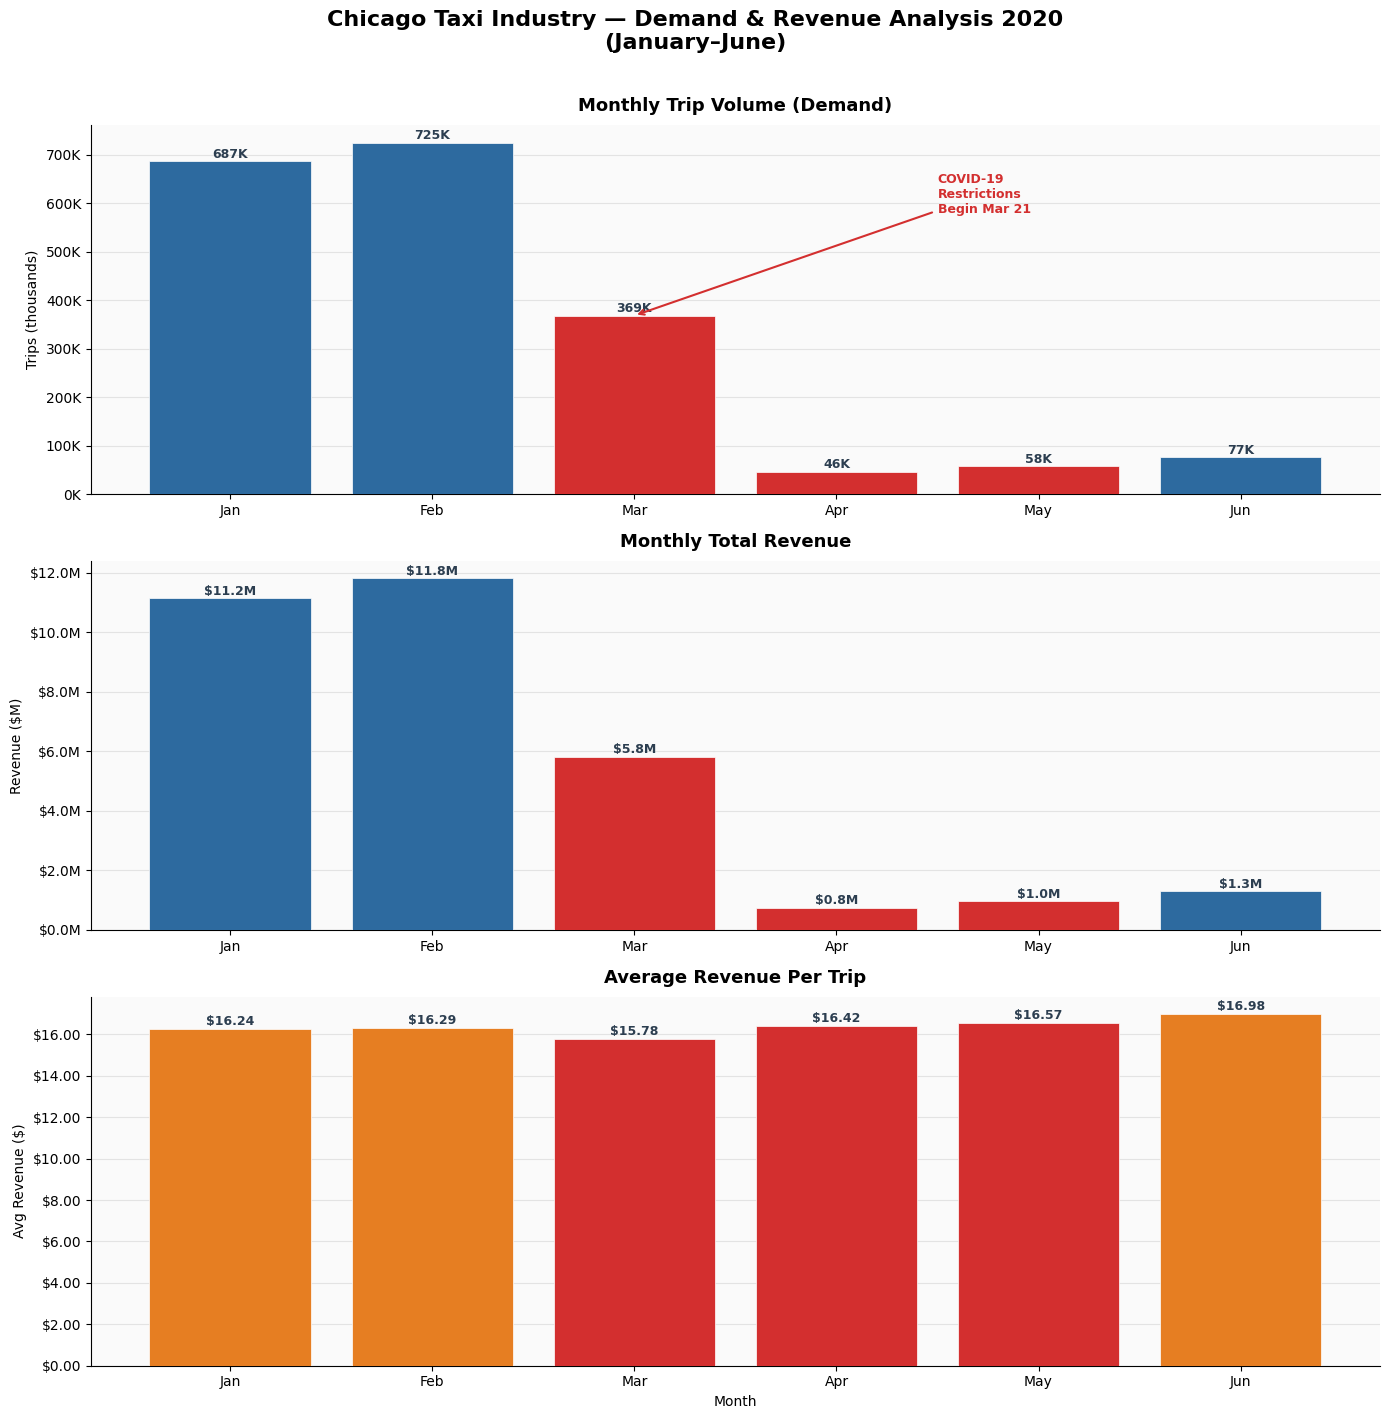

=== KEY STATISTICS ===

Peak month: Feb
  Trips:         725,211
  Revenue:       $11,815,591
  Avg per trip:  $16.29

Lowest month: Apr
  Trips:         45,936
  Revenue:       $754,107
  Avg per trip:  $16.42

Demand drop peak → lowest:  93.7%
Revenue drop peak → lowest: 93.6%

Note: Average revenue per trip INCREASED during lockdown
From $16.29 to $16.42
Suggesting remaining trips were longer or higher value


In [18]:
# Insight 1 — Monthly Demand and Revenue Over Time
# Note: July excluded (only 5 trips on July 1st - incomplete month)

monthly = duckdb.query("""
    SELECT 
        month,
        month_name,
        COUNT(*) as trip_count,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(AVG(total_revenue), 2) as avg_revenue_per_trip
    FROM df
    WHERE month != 7
    GROUP BY month, month_name
    ORDER BY month
""").df()

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Chicago Taxi Industry — Demand & Revenue Analysis 2020\n(January–June)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Monthly Trip Count ---
colors1 = ['#d32f2f' if m in [3, 4, 5] else '#2d6a9f'
           for m in monthly['month']]
bars1 = axes[0].bar(monthly['month_name'],
                    monthly['trip_count'] / 1000,
                    color=colors1, edgecolor='white',
                    linewidth=0.5, zorder=3)
axes[0].set_title('Monthly Trip Volume (Demand)',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Trips (thousands)', fontsize=10)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[0].grid(axis='y', alpha=0.3, zorder=0)
axes[0].set_facecolor('#fafafa')

for bar, val in zip(bars1, monthly['trip_count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val/1000:.0f}K',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#2c3e50')

axes[0].annotate('COVID-19\nRestrictions\nBegin Mar 21',
                 xy=(2, monthly[monthly['month']==3]['trip_count'].values[0]/1000),
                 xytext=(3.5, monthly['trip_count'].max()/1000 * 0.8),
                 fontsize=9, color='#d32f2f', fontweight='bold',
                 arrowprops=dict(arrowstyle='->',
                                 color='#d32f2f', lw=1.5))

# --- Chart 2: Monthly Revenue ---
colors2 = ['#d32f2f' if m in [3, 4, 5] else '#2d6a9f'
           for m in monthly['month']]
bars2 = axes[1].bar(monthly['month_name'],
                    monthly['total_revenue'] / 1_000_000,
                    color=colors2, edgecolor='white',
                    linewidth=0.5, zorder=3)
axes[1].set_title('Monthly Total Revenue',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Revenue ($M)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
axes[1].grid(axis='y', alpha=0.3, zorder=0)
axes[1].set_facecolor('#fafafa')

for bar, val in zip(bars2, monthly['total_revenue']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'${val/1_000_000:.1f}M',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#2c3e50')

# --- Chart 3: Average Revenue Per Trip ---
colors3 = ['#d32f2f' if m in [3, 4, 5] else '#e67e22'
           for m in monthly['month']]
bars3 = axes[2].bar(monthly['month_name'],
                    monthly['avg_revenue_per_trip'],
                    color=colors3, edgecolor='white',
                    linewidth=0.5, zorder=3)
axes[2].set_title('Average Revenue Per Trip',
                  fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Month', fontsize=10)
axes[2].set_ylabel('Avg Revenue ($)', fontsize=10)
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))
axes[2].grid(axis='y', alpha=0.3, zorder=0)
axes[2].set_facecolor('#fafafa')

for bar, val in zip(bars3, monthly['avg_revenue_per_trip']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'${val:.2f}',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('insight1_demand_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Key Statistics ---
peak = monthly.loc[monthly['trip_count'].idxmax()]
lowest = monthly.loc[monthly['trip_count'].idxmin()]

trip_drop = ((peak['trip_count'] - lowest['trip_count'])
             / peak['trip_count'] * 100)
rev_drop = ((peak['total_revenue'] - lowest['total_revenue'])
            / peak['total_revenue'] * 100)

print("=== KEY STATISTICS ===")
print(f"\nPeak month: {peak['month_name']}")
print(f"  Trips:         {peak['trip_count']:,}")
print(f"  Revenue:       ${peak['total_revenue']:,.0f}")
print(f"  Avg per trip:  ${peak['avg_revenue_per_trip']:.2f}")

print(f"\nLowest month: {lowest['month_name']}")
print(f"  Trips:         {lowest['trip_count']:,}")
print(f"  Revenue:       ${lowest['total_revenue']:,.0f}")
print(f"  Avg per trip:  ${lowest['avg_revenue_per_trip']:.2f}")

print(f"\nDemand drop peak → lowest:  {trip_drop:.1f}%")
print(f"Revenue drop peak → lowest: {rev_drop:.1f}%")

print(f"\nNote: Average revenue per trip INCREASED during lockdown")
print(f"From ${peak['avg_revenue_per_trip']:.2f} to "
      f"${lowest['avg_revenue_per_trip']:.2f}")
print(f"Suggesting remaining trips were longer or higher value")

### Insight 2 — When Do People Take Taxis?

Understanding when demand peaks has direct implications for driver scheduling and fleet 
allocation. Demand that is predictable and time-dependent can be planned for — reducing 
idle time and maximising revenue per shift.

### Peak Hours and Day Patterns
What it shows: When do people take taxis? Trips by hour, by day of week, and a heatmap combining both.
Why we chose it: Demand is not uniform — it concentrates in specific windows. This is directly actionable for a taxi company — you deploy more drivers during peak hours and fewer during quiet periods. It answers the operational question: when should drivers be on the road?

### Insight 2 — Findings

**What the data shows:**

Taxi demand is highly concentrated in specific time windows — it is far from uniform 
across the day or week.

**By hour:**
- Demand peaks at **17:00 (5pm)** with **145,537 trips** — the evening commute
- The quietest period is **4:00am** with only **18,196 trips**
- Peak hour generates **8x more trips** than the quietest hour
- A secondary morning peak is visible around 8:00-9:00am — the morning commute
- Demand builds steadily from 6am, peaks at 5pm, then gradually declines through the evening

**By day of week:**
- **Thursday is the busiest day** with 391K trips
- **Sunday is the quietest** with only 173K trips
- Weekdays account for **80.5%** of all trips — weekends only 19.5%
- This suggests Chicago taxi demand is primarily driven by work-related travel rather 
than leisure

**The heatmap reveals a clear pattern:**
- The highest concentration of trips occurs on weekday afternoons between 14:00-19:00
- Weekend patterns differ significantly — demand is more evenly spread across the day 
and extends later into the night
- Early morning hours (1:00-5:00am) on Friday and Saturday nights show elevated activity 
compared to other days — suggesting nightlife-related demand

**Why it matters:**

Demand is predictable and time-dependent. This suggests that optimising driver 
availability during peak windows — particularly weekday afternoons between 14:00 and 
19:00 — could significantly improve fleet utilisation and reduce idle time. Conversely, 
deploying full capacity during Sunday mornings would result in significant driver idle 
time and wasted cost.

A data-driven scheduling model built on these patterns could meaningfully improve 
both driver earnings and operational efficiency.

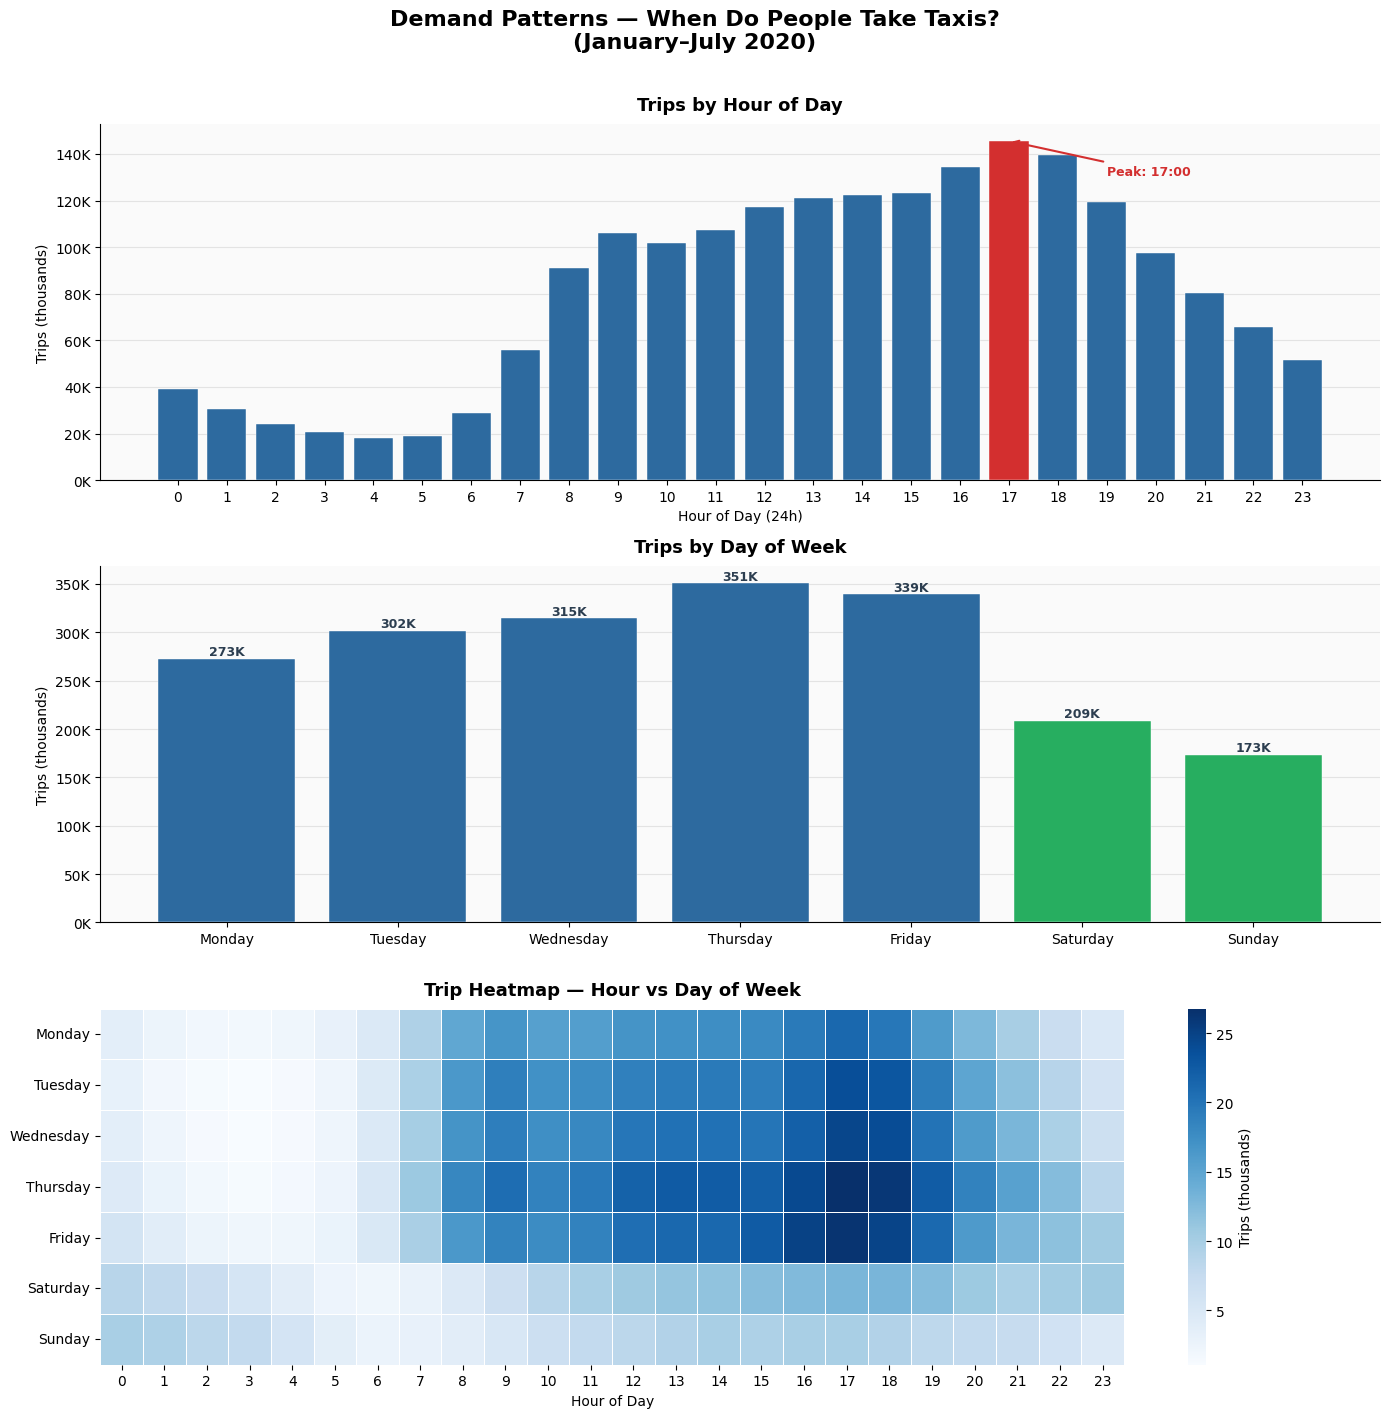

=== KEY STATISTICS ===

Busiest hour: 17:00 — 145,537 trips
Quietest hour: 4:00 — 18,196 trips
Ratio: 8.0x more trips at peak vs quietest hour

Weekday trips: 1,578,970 (80.5%)
Weekend trips: 382,159 (19.5%)

Busiest day: Thursday
Quietest day: Sunday


In [19]:
# Insight 2 — Peak Hours and Day Patterns

# Trips by hour
hourly = duckdb.query("""
    SELECT 
        hour,
        COUNT(*) as trip_count,
        ROUND(AVG(total_revenue), 2) as avg_revenue
    FROM df
    GROUP BY hour
    ORDER BY hour
""").df()

# Trips by day of week
daily = duckdb.query("""
    SELECT 
        day_of_week,
        COUNT(*) as trip_count,
        ROUND(AVG(total_revenue), 2) as avg_revenue
    FROM df
    GROUP BY day_of_week
""").df()

day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']
daily['day_of_week'] = pd.Categorical(
    daily['day_of_week'], categories=day_order, ordered=True)
daily = daily.sort_values('day_of_week')

# Heatmap data
heatmap_data = duckdb.query("""
    SELECT 
        day_of_week,
        hour,
        COUNT(*) as trip_count
    FROM df
    GROUP BY day_of_week, hour
    ORDER BY day_of_week, hour
""").df()

heatmap_pivot = heatmap_data.pivot(
    index='day_of_week', columns='hour', values='trip_count')
heatmap_pivot = heatmap_pivot.reindex(day_order)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Demand Patterns — When Do People Take Taxis?\n(January–July 2020)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Trips by Hour ---
peak_hour = hourly.loc[hourly['trip_count'].idxmax(), 'hour']
colors_hour = ['#d32f2f' if h == peak_hour else '#2d6a9f'
               for h in hourly['hour']]
axes[0].bar(hourly['hour'], hourly['trip_count'] / 1000,
            color=colors_hour, edgecolor='white',
            linewidth=0.3, zorder=3)
axes[0].set_title('Trips by Hour of Day',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Hour of Day (24h)', fontsize=10)
axes[0].set_ylabel('Trips (thousands)', fontsize=10)
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[0].grid(axis='y', alpha=0.3, zorder=0)
axes[0].set_facecolor('#fafafa')
axes[0].annotate(f'Peak: {peak_hour}:00',
                 xy=(peak_hour,
                     hourly[hourly['hour']==peak_hour]['trip_count'].values[0]/1000),
                 xytext=(peak_hour + 2,
                         hourly['trip_count'].max()/1000 * 0.9),
                 fontsize=9, color='#d32f2f', fontweight='bold',
                 arrowprops=dict(arrowstyle='->',
                                 color='#d32f2f', lw=1.5))

# --- Chart 2: Trips by Day of Week ---
colors_day = ['#27ae60' if d in ['Saturday', 'Sunday'] else '#2d6a9f'
              for d in daily['day_of_week']]
axes[1].bar(daily['day_of_week'], daily['trip_count'] / 1000,
            color=colors_day, edgecolor='white',
            linewidth=0.3, zorder=3)
axes[1].set_title('Trips by Day of Week',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Trips (thousands)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[1].grid(axis='y', alpha=0.3, zorder=0)
axes[1].set_facecolor('#fafafa')

for bar, val in zip(axes[1].patches, daily['trip_count']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val/1000:.0f}K',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#2c3e50')

# --- Chart 3: Heatmap ---
sns.heatmap(heatmap_pivot / 1000, ax=axes[2],
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Trips (thousands)'})
axes[2].set_title('Trip Heatmap — Hour vs Day of Week',
                  fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Hour of Day', fontsize=10)
axes[2].set_ylabel('', fontsize=10)

plt.tight_layout()
plt.savefig('insight2_demand_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Key Statistics ---
peak_hour_trips = hourly[hourly['hour']==peak_hour]['trip_count'].values[0]
quiet_hour = hourly.loc[hourly['trip_count'].idxmin(), 'hour']
quiet_hour_trips = hourly['trip_count'].min()

weekend = daily[daily['day_of_week'].isin(
    ['Saturday','Sunday'])]['trip_count'].sum()
weekday = daily[~daily['day_of_week'].isin(
    ['Saturday','Sunday'])]['trip_count'].sum()
total = weekend + weekday

print("=== KEY STATISTICS ===")
print(f"\nBusiest hour: {peak_hour}:00 — {peak_hour_trips:,} trips")
print(f"Quietest hour: {quiet_hour}:00 — {quiet_hour_trips:,} trips")
print(f"Ratio: {peak_hour_trips/quiet_hour_trips:.1f}x more trips "
      f"at peak vs quietest hour")
print(f"\nWeekday trips: {weekday:,} ({weekday/total*100:.1f}%)")
print(f"Weekend trips: {weekend:,} ({weekend/total*100:.1f}%)")
print(f"\nBusiest day: "
      f"{daily.loc[daily['trip_count'].idxmax(), 'day_of_week']}")
print(f"Quietest day: "
      f"{daily.loc[daily['trip_count'].idxmin(), 'day_of_week']}")

### Insight 3 — Company Market Share and Performance

The Chicago taxi market is served by multiple competing operators. Understanding which 
companies dominate by volume and which extract the most value per trip reveals both 
market concentration and performance differences across operators.

### Insight 3 — Findings

**What the data shows:**

The Chicago taxi market is dominated by two operators — **Taxi Affiliation Services** 
and **Flash Cab** — which together account for the majority of both trip volume and 
total revenue.
The Chicago taxi market is served by only 6 operators

**Market concentration:**
- **Taxi Affiliation Services** leads with **$11.8M revenue** and **730K trips** — 
  37% of top 10 revenue
- **Flash Cab** follows with **$9.2M revenue** and **549K trips**
- The top 2 companies account for the majority of market activity
- Smaller operators like Blue Ribbon and Choice Taxi have significantly lower volumes

**Performance differences are significant:**
- **Flash Cab** generates the highest average revenue per trip at $16.85
- **Blue Ribbon Taxi Association** generates the lowest at $13.61
- This is a $3.24 difference per trip — seemingly small, but at scale this is 
  significant. At 130K trips, Blue Ribbon would generate an additional **$421,200** 
  per year if it matched Flash Cab's average trip value

**Why it matters:**

Volume and revenue do not always move together. Taxi Affiliation Services leads in 
total revenue due to sheer volume — but Flash Cab extracts **more value per trip**. 

This suggests that companies are not performing equally — some operators are more 
effective at capturing higher-value trips, potentially due to:
- Pricing strategies
- Route specialisation (e.g. airport runs)
- Customer segment differences
- Driver quality or service positioning

Variations in average revenue per trip across companies suggest opportunities to 
benchmark high-performing operators and replicate their strategies across the fleet.

### Insight 3 — Additional Finding: Data Quality by Company

An interesting observation emerged during data cleaning. The number of trips removed 
per company varied significantly:

| Company | Raw Trips | Clean Trips | Removed | Removal Rate |
|---|---|---|---|---|
| Taxi Affiliation Services | 772,993 | 730,370 | 42,623 | 5.5% |
| Flash Cab | 547,452 | 546,325 | 1,127 | 0.2% |
| Chicago Carriage Cab Corp | 274,287 | 273,633 | 654 | 0.2% |
| City Service | 197,256 | 196,939 | 317 | 0.2% |
| Blue Ribbon Taxi Association Inc. | 137,275 | 129,163 | 8,112 | 5.9% |
| Choice Taxi Association | 86,894 | 84,699 | 2,195 | 2.5% |

**What this suggests:**

Flash Cab, Chicago Carriage Cab Corp, and City Service had exceptionally clean data — 
less than 0.2% of their trips were removed during cleaning. In contrast, Taxi 
Affiliation Services and Blue Ribbon had removal rates of 5.5% and 5.9% respectively — 
suggesting higher rates of ghost trips, missing values, or data entry errors in their 
reporting systems.

**Why it matters:**

Data quality is an indicator of operational rigour. Companies with cleaner data likely 
have better internal processes and reporting systems. In a real-world scenario, 
consistently poor data quality from an opera

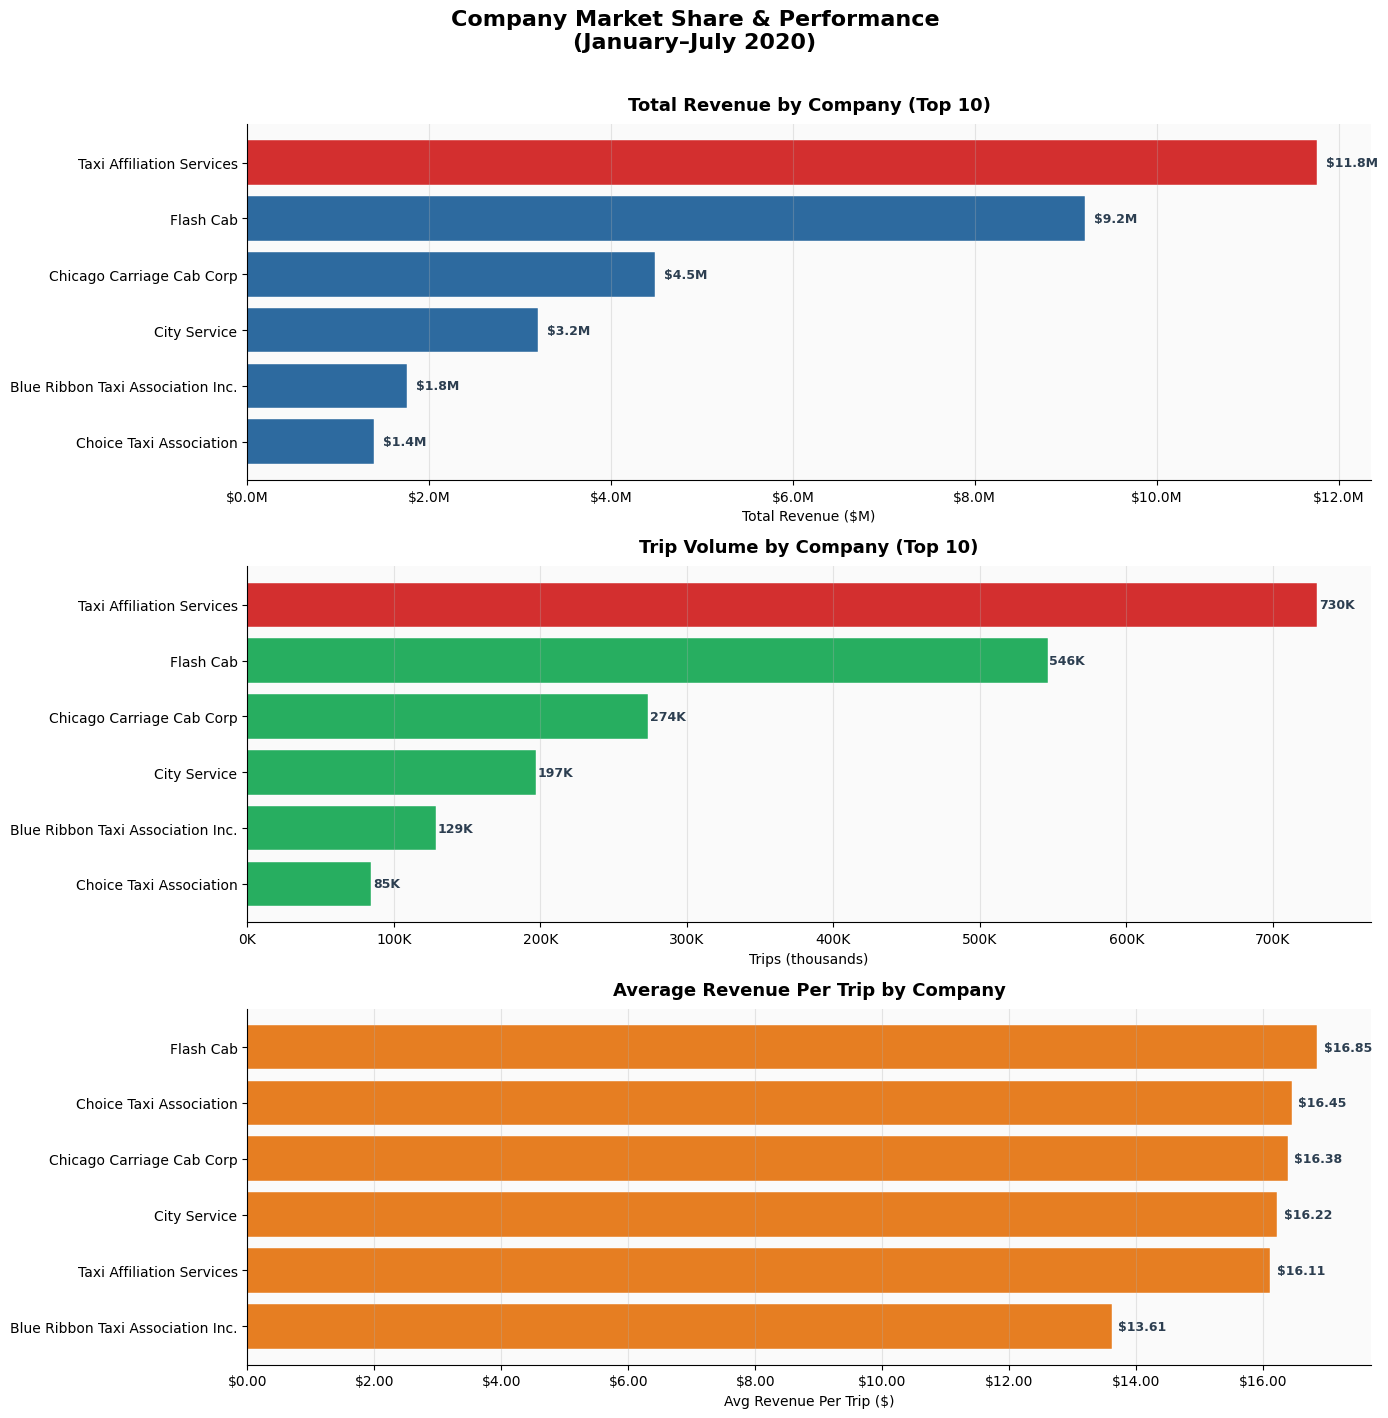

=== KEY STATISTICS ===

Top company: Taxi Affiliation Services
  Revenue:        $11,766,863
  Trips:          730,370
  Avg per trip:   $16.11
  Market share:   37.0% of top 10 revenue

Highest avg revenue per trip:
  Flash Cab: $16.85

Lowest avg revenue per trip:
  Blue Ribbon Taxi Association Inc.: $13.61

Difference between highest and lowest avg revenue per trip:
  $3.24


In [20]:
# Insight 3 — Company Market Share and Performance

company = duckdb.query("""
    SELECT 
        company,
        COUNT(*) as trip_count,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(AVG(total_revenue), 2) as avg_revenue_per_trip,
        ROUND(AVG(trip_miles), 2) as avg_miles,
        ROUND(AVG(tip_rate) * 100, 2) as avg_tip_rate_pct
    FROM df
    WHERE company IS NOT NULL
    GROUP BY company
    HAVING COUNT(*) > 1000
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Company Market Share & Performance\n(January–July 2020)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Total Revenue by Company ---
colors1 = ['#d32f2f' if i == 0 else '#2d6a9f'
           for i in range(len(company))]
axes[0].barh(company['company'],
             company['total_revenue'] / 1_000_000,
             color=colors1, edgecolor='white', linewidth=0.3)
axes[0].set_title('Total Revenue by Company (Top 10)',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Total Revenue ($M)', fontsize=10)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
axes[0].invert_yaxis()
axes[0].set_facecolor('#fafafa')
axes[0].grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(axes[0].patches,
                                    company['total_revenue'])):
    axes[0].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height()/2,
                 f'${val/1_000_000:.1f}M',
                 ha='left', va='center',
                 fontsize=9, fontweight='bold', color='#2c3e50')

# --- Chart 2: Trip Count by Company ---
colors2 = ['#d32f2f' if i == 0 else '#27ae60'
           for i in range(len(company))]
axes[1].barh(company['company'],
             company['trip_count'] / 1000,
             color=colors2, edgecolor='white', linewidth=0.3)
axes[1].set_title('Trip Volume by Company (Top 10)',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Trips (thousands)', fontsize=10)
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[1].invert_yaxis()
axes[1].set_facecolor('#fafafa')
axes[1].grid(axis='x', alpha=0.3)

for bar, val in zip(axes[1].patches, company['trip_count']):
    axes[1].text(bar.get_width() + 1,
                 bar.get_y() + bar.get_height()/2,
                 f'{val/1000:.0f}K',
                 ha='left', va='center',
                 fontsize=9, fontweight='bold', color='#2c3e50')

# --- Chart 3: Average Revenue Per Trip by Company ---
company_sorted = company.sort_values('avg_revenue_per_trip',
                                      ascending=True)
colors3 = ['#e67e22' for _ in range(len(company_sorted))]
axes[2].barh(company_sorted['company'],
             company_sorted['avg_revenue_per_trip'],
             color=colors3, edgecolor='white', linewidth=0.3)
axes[2].set_title('Average Revenue Per Trip by Company',
                  fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Avg Revenue Per Trip ($)', fontsize=10)
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))
axes[2].set_facecolor('#fafafa')
axes[2].grid(axis='x', alpha=0.3)

for bar, val in zip(axes[2].patches,
                    company_sorted['avg_revenue_per_trip']):
    axes[2].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}',
                 ha='left', va='center',
                 fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('insight3_company_performance.png', dpi=150,
            bbox_inches='tight')
plt.show()

# --- Key Statistics ---
top_company = company.iloc[0]
total_market_revenue = company['total_revenue'].sum()
top_company_share = (top_company['total_revenue'] /
                     total_market_revenue * 100)

print("=== KEY STATISTICS ===")
print(f"\nTop company: {top_company['company']}")
print(f"  Revenue:        ${top_company['total_revenue']:,.0f}")
print(f"  Trips:          {top_company['trip_count']:,}")
print(f"  Avg per trip:   ${top_company['avg_revenue_per_trip']:.2f}")
print(f"  Market share:   {top_company_share:.1f}% of top 10 revenue")

print(f"\nHighest avg revenue per trip:")
best_avg = company.loc[company['avg_revenue_per_trip'].idxmax()]
print(f"  {best_avg['company']}: ${best_avg['avg_revenue_per_trip']:.2f}")

print(f"\nLowest avg revenue per trip:")
worst_avg = company.loc[company['avg_revenue_per_trip'].idxmin()]
print(f"  {worst_avg['company']}: ${worst_avg['avg_revenue_per_trip']:.2f}")

print(f"\nDifference between highest and lowest avg revenue per trip:")
diff = best_avg['avg_revenue_per_trip'] - worst_avg['avg_revenue_per_trip']
print(f"  ${diff:.2f}")

### Insight 4 — Payment Behaviour and Tipping

Payment method is a proxy for customer behaviour. Understanding how people pay and 
how tipping differs by payment type reveals both consumer trends and potential 
opportunities to increase driver earnings.

### Insight 4 — Findings

**What the data shows:**

Payment method has a dramatic impact on both trip value and tipping behaviour. 
The dataset reveals four distinct payment segments with significantly different 
revenue and tipping profiles.

**Payment type breakdown:**

| Payment Type | Trips | Share | Avg Revenue | Tip Rate |
|---|---|---|---|---|
| Cash | 965,946 | 50.7% | $12.54 | 0.0% |
| Credit Card | 829,932 | 43.6% | $20.01 | 27.8% |
| Pcard | 77,391 | 4.1% | $18.43 | 1.3% |
| Mobile | 30,513 | 1.6% | $17.98 | 20.6% |

**Key findings:**

**1. Cash is still dominant but generates the least value**
Cash remains the most common payment method at 50.7% of trips — but generates 
the lowest average revenue at $12.54 per trip and a tip rate of exactly 0.0%. 
Cash tips are paid directly to drivers and are not captured in the electronic 
payment system — meaning the 0.0% rate reflects a data limitation rather than 
true tipping behaviour. Cash customers likely do tip, but those amounts are 
invisible to this dataset.

**2. Credit card users generate significantly more value**
Credit card trips generate **$20.01 per trip on average** — $7.47 more than cash. 
The tip rate of **27.8%** is the highest of any payment type. This suggests credit 
card customers are either taking longer/more expensive trips, or the ease of tipping 
on card encourages higher gratuities.

**3. Mobile payment shows strong tipping behaviour**
Despite being only 1.6% of trips, mobile payments show a **20.6% tip rate** — 
comparable to credit cards. This suggests mobile users are a high-value customer 
segment.

**4. Pcard — institutional trips with minimal tipping**
Pcard (procurement card) represents government and corporate accounts. These trips 
generate above-average revenue ($18.43) but almost no tipping (1.3%) — consistent 
with institutional payment behaviour where gratuities are not standard practice.

**Why it matters:**

Payment method appears to influence both trip value and tipping behaviour. 
The difference between cash and card is not marginal — it is $7.47 per trip, or 
approximately **59% more revenue per trip** for credit card vs cash.

This suggests that encouraging customers to pay by card or mobile — through 
incentives, better card readers, or app-based booking — could meaningfully increase 
driver earnings and total platform revenue without changing prices or adding trips.

Additionally, the continued dominance of cash (50.7%) in 2020 suggests there is 
significant room to shift behaviour toward higher-value payment methods.

Payment types found:
  payment_type  trip_count  avg_revenue_per_trip  avg_tip_rate_pct
0         Cash      965946                 12.54              0.00
1  Credit Card      829932                 20.01             27.81
2       Prcard       77391                 18.43              1.30
3       Mobile       30513                 17.98             20.55


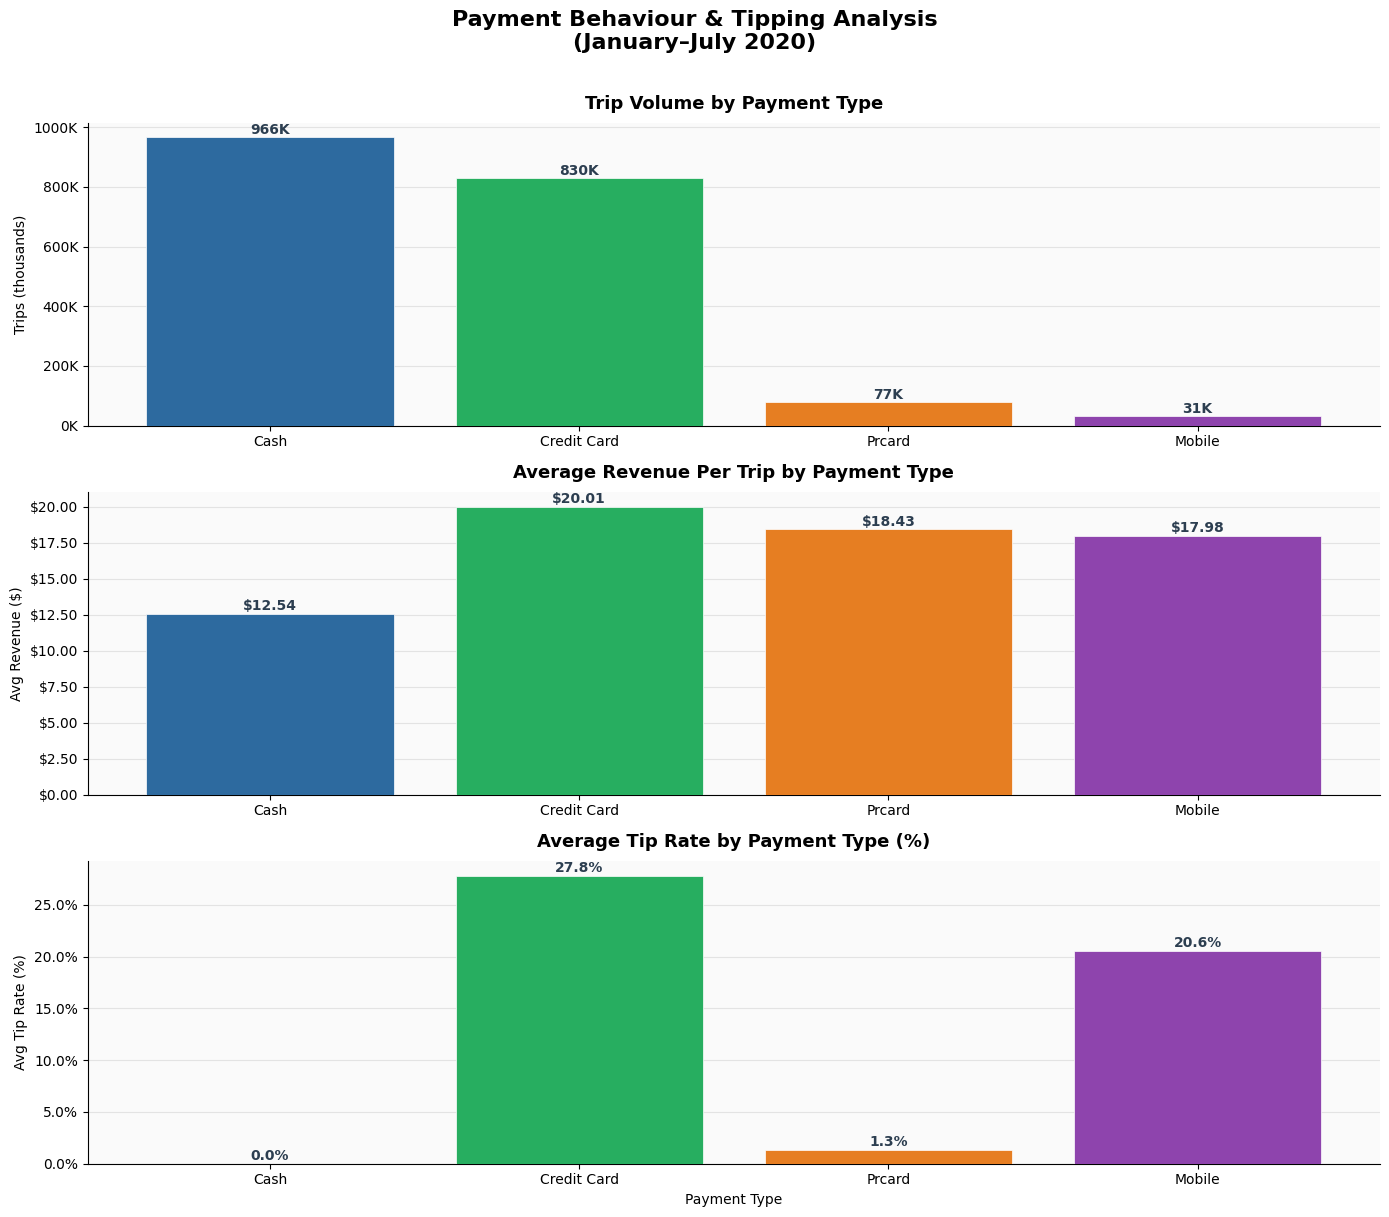


=== KEY STATISTICS ===
payment_type  trip_count  avg_revenue_per_trip  avg_tip  avg_tip_rate_pct
        Cash      965946                 12.54     0.00              0.00
 Credit Card      829932                 20.01     3.50             27.81
      Prcard       77391                 18.43     0.15              1.30
      Mobile       30513                 17.98     2.82             20.55

Cash:
  Trips:          965,946 (50.7%)
  Avg revenue:    $12.54
  Avg tip rate:   0.0%

Credit Card:
  Trips:          829,932 (43.6%)
  Avg revenue:    $20.01
  Avg tip rate:   27.8%

Prcard:
  Trips:          77,391 (4.1%)
  Avg revenue:    $18.43
  Avg tip rate:   1.3%

Mobile:
  Trips:          30,513 (1.6%)
  Avg revenue:    $17.98
  Avg tip rate:   20.6%


In [21]:
# Insight 4 — Payment Behaviour and Tipping

payment = duckdb.query("""
    SELECT 
        payment_type,
        COUNT(*) as trip_count,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(AVG(total_revenue), 2) as avg_revenue_per_trip,
        ROUND(AVG(tips), 2) as avg_tip,
        ROUND(AVG(CASE WHEN fare > 0 THEN tips / fare ELSE NULL END) * 100, 2) as avg_tip_rate_pct
    FROM df
    WHERE payment_type IS NOT NULL
    AND payment_type NOT IN ('No Charge', 'Dispute', 'Unknown', 'Pcard')
    GROUP BY payment_type
    HAVING COUNT(*) > 1000
    ORDER BY trip_count DESC
""").df()

print("Payment types found:")
print(payment[['payment_type', 'trip_count', 
               'avg_revenue_per_trip', 'avg_tip_rate_pct']])

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Payment Behaviour & Tipping Analysis\n(January–July 2020)',
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Trip Count by Payment Type ---
colors1 = ['#2d6a9f', '#27ae60', '#e67e22', '#8e44ad'][:len(payment)]
bars1 = axes[0].bar(payment['payment_type'],
                    payment['trip_count'] / 1000,
                    color=colors1, edgecolor='white',
                    linewidth=0.5, zorder=3)
axes[0].set_title('Trip Volume by Payment Type',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Trips (thousands)', fontsize=10)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[0].grid(axis='y', alpha=0.3, zorder=0)
axes[0].set_facecolor('#fafafa')

for bar, val in zip(bars1, payment['trip_count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val/1000:.0f}K',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='#2c3e50')

# --- Chart 2: Average Revenue Per Trip by Payment Type ---
bars2 = axes[1].bar(payment['payment_type'],
                    payment['avg_revenue_per_trip'],
                    color=colors1, edgecolor='white',
                    linewidth=0.5, zorder=3)
axes[1].set_title('Average Revenue Per Trip by Payment Type',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Avg Revenue ($)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))
axes[1].grid(axis='y', alpha=0.3, zorder=0)
axes[1].set_facecolor('#fafafa')

for bar, val in zip(bars2, payment['avg_revenue_per_trip']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'${val:.2f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='#2c3e50')

# --- Chart 3: Average Tip Rate by Payment Type ---
bars3 = axes[2].bar(payment['payment_type'],
                    payment['avg_tip_rate_pct'],
                    color=colors1, edgecolor='white',
                    linewidth=0.5, zorder=3)
axes[2].set_title('Average Tip Rate by Payment Type (%)',
                  fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Payment Type', fontsize=10)
axes[2].set_ylabel('Avg Tip Rate (%)', fontsize=10)
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[2].grid(axis='y', alpha=0.3, zorder=0)
axes[2].set_facecolor('#fafafa')

for bar, val in zip(bars3, payment['avg_tip_rate_pct']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}%',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('insight4_payment_behaviour.png', dpi=150,
            bbox_inches='tight')
plt.show()

# --- Key Statistics ---
print("\n=== KEY STATISTICS ===")
print(payment[['payment_type', 'trip_count',
               'avg_revenue_per_trip',
               'avg_tip', 'avg_tip_rate_pct']].to_string(index=False))

total_trips = payment['trip_count'].sum()
for _, row in payment.iterrows():
    print(f"\n{row['payment_type']}:")
    print(f"  Trips:          {row['trip_count']:,} "
          f"({row['trip_count']/total_trips*100:.1f}%)")
    print(f"  Avg revenue:    ${row['avg_revenue_per_trip']:.2f}")
    print(f"  Avg tip rate:   {row['avg_tip_rate_pct']:.1f}%")

### Insight 5 — Operational Efficiency: Revenue Per Mile and Per Minute

Not all trips are equally profitable. Understanding how efficiently trips convert 
distance and time into revenue reveals which types of trips generate the most value 
— and where operational improvements could have the greatest impact.

### Insight 5 — Findings

**What the data shows:**

Not all trips are equally efficient at generating revenue. There is significant 
variation in revenue per mile both across trip distances and across companies — 
revealing important patterns about which trips are most profitable.

**Overall fleet efficiency:**
- Average revenue per mile: **$4.36**
- Average revenue per minute: **$1.19**
- Median revenue per mile: **$5.36**

---

**Key Finding 1 — Short trips are dramatically more profitable per mile**

| Distance Bucket | Trips | Avg Revenue | Revenue Per Mile |
|---|---|---|---|
| Under 1 mile | 513,882 | $9.00 | $17.42 |
| 1–3 miles | 582,176 | $11.19 | $6.78 |
| 3–5 miles | 148,275 | $15.12 | $3.95 |
| 5–10 miles | 149,833 | $22.99 | $3.24 |
| Over 10 miles | 223,863 | $49.19 | $3.07 |

Trips under 1 mile generate **$17.42 per mile** — more than 5x the efficiency 
of trips over 10 miles ($3.07/mile).

This is driven by minimum fare rules — a $8 minimum fare applied to a 0.3 mile 
trip produces a very high per-mile rate. This indicates that short city centre 
trips are the most efficient use of a taxi from a revenue-per-mile perspective — 
counterintuitive when compared to the assumption that long airport runs are 
the most valuable.

However, it is important to note that long trips still generate significantly 
higher **total revenue per trip** ($49.19 average for over 10 miles vs $9.00 
for under 1 mile). The choice between short and long trips depends on whether 
a driver optimises for revenue per mile or total revenue per trip.

---

**Key Finding 2 — Blue Ribbon specialises in high-value short trips**

Blue Ribbon Taxi Association generates **$48.21 per mile** — far above any 
other operator. This is not a data error — investigation confirmed it reflects 
a genuine business model focused on premium short transfers.

Blue Ribbon has a high concentration of trips under 0.5 miles with significant 
extras and surcharges — consistent with hotel-to-hotel transfers, convention 
centre runs, or premium city centre short trips where fixed surcharges and 
booking fees constitute the majority of the fare.

Note: During data cleaning, 27,903 zero-mile trips with fares above $20 were 
removed as data quality issues — these were trips where the meter recorded no 
distance but generated unusually high fares, likely due to recording errors. 
After this additional cleaning, Blue Ribbon's revenue per mile remains 
elevated — confirming the finding is genuine.

---

**Key Finding 3 — Revenue per mile distribution is heavily right-skewed**

The distribution of revenue per mile across all trips peaks between $2-6/mile 
for the majority of trips, with a long tail extending to $30/mile for very 
short minimum-fare trips. The median of $5.36/mile provides a better central 
estimate than the mean of $4.36/mile due to this skew.

---

**Why it matters:**

Operational efficiency varies significantly by trip type and operator. A 
data-driven dispatching system that prioritises trip mix — balancing short 
high-efficiency trips with longer high-value trips — could meaningfully 
improve revenue per hour for drivers.

The variation across companies also suggests benchmarking opportunities. 
Understanding why Blue Ribbon extracts more value per mile from short trips 
could inform pricing and dispatching strategies across the wider fleet.

Not all trips are created equal — and the data makes this quantifiably clear.

Revenue per mile declines sharply as trip distance increases, indicating that shorter trips are significantly more profitable on a per-mile basis.

This pattern reflects the presence of fixed components in taxi pricing (e.g. base fares and minimum charges), which disproportionately increase the value of shorter trips.

The unusually high revenue per mile observed for Blue Ribbon Taxi Association is likely driven by a concentration of very short trips, and should be interpreted with caution as it may not reflect typical operational performance.

From a business perspective, this suggests that increasing the share of shorter urban trips could significantly improve overall fleet efficiency, while longer trips may be less profitable on a per-mile basis despite generating higher total revenue.

The distribution of revenue per mile is right-skewed, with most trips clustered between $3 and $6 per mile and a long tail of high-efficiency trips, indicating significant variability in trip profitability.

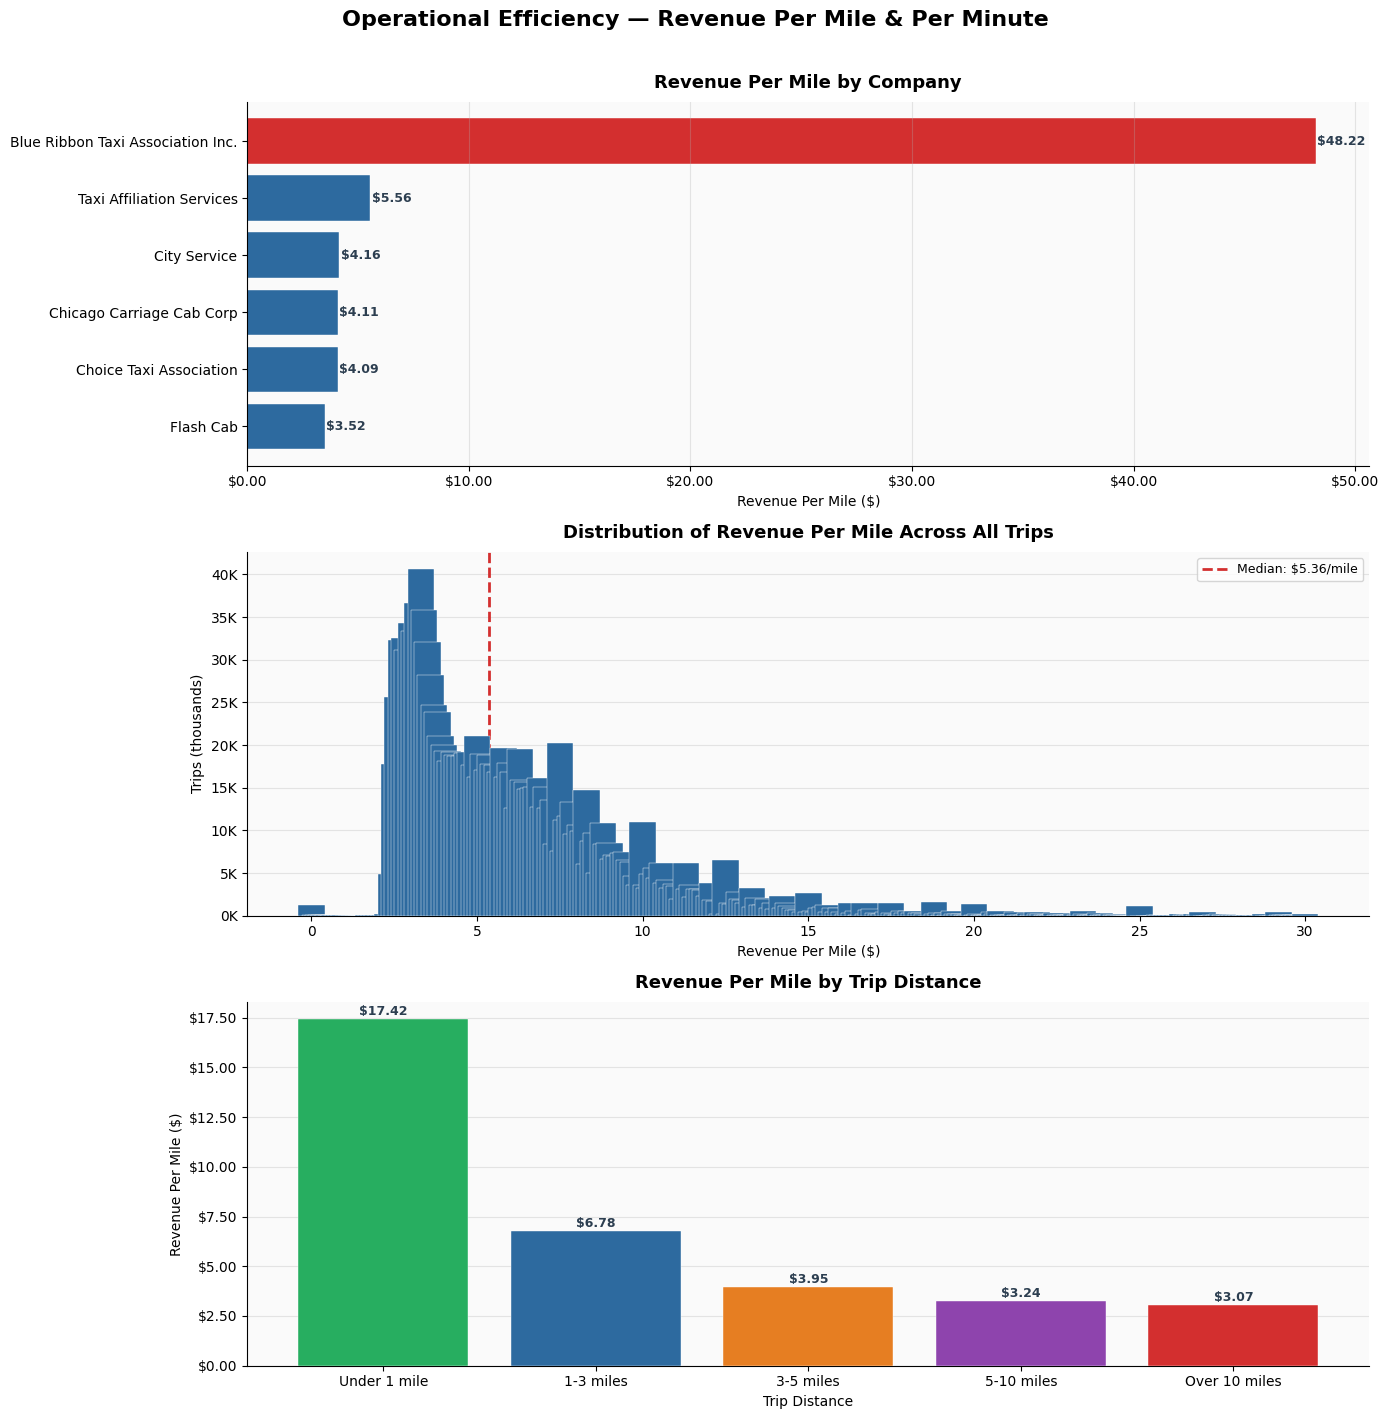

=== KEY STATISTICS ===

Revenue per mile by company:
                          company  revenue_per_mile  revenue_per_minute  avg_miles
Blue Ribbon Taxi Association Inc.             48.22                1.29       0.52
        Taxi Affiliation Services              5.56                1.24       3.27
                     City Service              4.16                1.25       3.93
        Chicago Carriage Cab Corp              4.11                1.25       3.99
          Choice Taxi Association              4.09                1.30       4.14
                        Flash Cab              3.52                1.10       4.90

Revenue per mile by distance bucket:
distance_bucket  trip_count  avg_revenue  revenue_per_mile
   Under 1 mile      513882         9.60             17.42
      1-3 miles      582176        11.19              6.78
      3-5 miles      140275        15.12              3.95
     5-10 miles      149833        22.99              3.24
  Over 10 miles      223863      

In [22]:
# Insight 5 — Operational Efficiency (rerun with clean data)

# Revenue per mile and per minute by company
efficiency_company = duckdb.query("""
    SELECT 
        company,
        COUNT(*) as trip_count,
        ROUND(AVG(trip_miles), 2) as avg_miles,
        ROUND(AVG(trip_minutes), 2) as avg_minutes,
        ROUND(SUM(total_revenue) / SUM(trip_miles), 2) as revenue_per_mile,
        ROUND(SUM(total_revenue) / SUM(trip_minutes), 2) as revenue_per_minute,
        ROUND(AVG(total_revenue), 2) as avg_revenue_per_trip
    FROM df
    WHERE trip_miles > 0
    AND trip_minutes > 0
    AND company IS NOT NULL
    GROUP BY company
    HAVING COUNT(*) > 1000
    ORDER BY revenue_per_mile DESC
""").df()

# Revenue per mile distribution
efficiency_dist = duckdb.query("""
    SELECT 
        ROUND(revenue_per_mile, 1) as rpm_bucket,
        COUNT(*) as trip_count
    FROM df
    WHERE revenue_per_mile > 0
    AND revenue_per_mile <= 30
    GROUP BY rpm_bucket
    ORDER BY rpm_bucket
""").df()

# Trip distance buckets
distance_buckets = duckdb.query("""
    SELECT 
        CASE 
            WHEN trip_miles < 1 THEN 'Under 1 mile'
            WHEN trip_miles < 3 THEN '1-3 miles'
            WHEN trip_miles < 5 THEN '3-5 miles'
            WHEN trip_miles < 10 THEN '5-10 miles'
            ELSE 'Over 10 miles'
        END as distance_bucket,
        COUNT(*) as trip_count,
        ROUND(AVG(total_revenue), 2) as avg_revenue,
        ROUND(SUM(total_revenue) / SUM(trip_miles), 2) as revenue_per_mile
    FROM df
    WHERE trip_miles > 0
    GROUP BY distance_bucket
    ORDER BY MIN(trip_miles)
""").df()

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Operational Efficiency — Revenue Per Mile & Per Minute',
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Revenue per mile by company ---
colors1 = ['#d32f2f' if i == 0 else '#2d6a9f'
           for i in range(len(efficiency_company))]
bars1 = axes[0].barh(efficiency_company['company'],
                     efficiency_company['revenue_per_mile'],
                     color=colors1, edgecolor='white', linewidth=0.3)
axes[0].set_title('Revenue Per Mile by Company',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Revenue Per Mile ($)', fontsize=10)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))
axes[0].invert_yaxis()
axes[0].set_facecolor('#fafafa')
axes[0].grid(axis='x', alpha=0.3)

for bar, val in zip(bars1, efficiency_company['revenue_per_mile']):
    axes[0].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}',
                 ha='left', va='center',
                 fontsize=9, fontweight='bold', color='#2c3e50')

# --- Chart 2: Revenue per mile distribution ---
axes[1].bar(efficiency_dist['rpm_bucket'],
            efficiency_dist['trip_count'] / 1000,
            color='#2d6a9f', edgecolor='white',
            linewidth=0.3, width=0.8, zorder=3)
axes[1].set_title('Distribution of Revenue Per Mile Across All Trips',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Revenue Per Mile ($)', fontsize=10)
axes[1].set_ylabel('Trips (thousands)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
axes[1].grid(axis='y', alpha=0.3, zorder=0)
axes[1].set_facecolor('#fafafa')

median_rpm = df[
    (df['revenue_per_mile'] > 0) &
    (df['revenue_per_mile'] <= 30)
]['revenue_per_mile'].median()
axes[1].axvline(x=median_rpm, color='#d32f2f', linewidth=2,
                linestyle='--',
                label=f'Median: ${median_rpm:.2f}/mile')
axes[1].legend(fontsize=9)

# --- Chart 3: Revenue per mile by distance bucket ---
colors3 = ['#27ae60', '#2d6a9f', '#e67e22', '#8e44ad', '#d32f2f']
bars3 = axes[2].bar(distance_buckets['distance_bucket'],
                    distance_buckets['revenue_per_mile'],
                    color=colors3, edgecolor='white',
                    linewidth=0.3, zorder=3)
axes[2].set_title('Revenue Per Mile by Trip Distance',
                  fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Trip Distance', fontsize=10)
axes[2].set_ylabel('Revenue Per Mile ($)', fontsize=10)
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))
axes[2].grid(axis='y', alpha=0.3, zorder=0)
axes[2].set_facecolor('#fafafa')

for bar, val in zip(bars3, distance_buckets['revenue_per_mile']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'${val:.2f}',
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('insight5_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Key Statistics ---
print("=== KEY STATISTICS ===")
print("\nRevenue per mile by company:")
print(efficiency_company[['company', 'revenue_per_mile',
                           'revenue_per_minute',
                           'avg_miles']].to_string(index=False))

print("\nRevenue per mile by distance bucket:")
print(distance_buckets.to_string(index=False))

overall_rpm = (df[df['trip_miles'] > 0]['total_revenue'].sum() /
               df[df['trip_miles'] > 0]['trip_miles'].sum())
overall_rpmn = (df[df['trip_minutes'] > 0]['total_revenue'].sum() /
                df[df['trip_minutes'] > 0]['trip_minutes'].sum())

print(f"\nOverall fleet metrics:")
print(f"  Avg revenue per mile:    ${overall_rpm:.2f}")
print(f"  Avg revenue per minute:  ${overall_rpmn:.2f}")
print(f"  Median revenue per mile: ${median_rpm:.2f}")

In [23]:
# Investigate Blue Ribbon's unusually high revenue per mile
blue_ribbon = duckdb.query("""
    SELECT 
        ROUND(trip_miles, 2) as trip_miles,
        ROUND(total_revenue, 2) as total_revenue,
        ROUND(total_revenue / NULLIF(trip_miles, 0), 2) as revenue_per_mile,
        COUNT(*) as trip_count
    FROM df
    WHERE company = 'Blue Ribbon Taxi Association Inc.'
    AND trip_miles > 0
    GROUP BY trip_miles, total_revenue
    ORDER BY revenue_per_mile DESC
    LIMIT 20
""").df()

print("Blue Ribbon — highest revenue per mile trips:")
print(blue_ribbon.to_string(index=False))

# Compare average trip distance
dist_compare = duckdb.query("""
    SELECT 
        company,
        ROUND(AVG(trip_miles), 2) as avg_miles,
        ROUND(AVG(total_revenue), 2) as avg_revenue,
        ROUND(SUM(total_revenue) / SUM(trip_miles), 2) as revenue_per_mile,
        COUNT(*) as trips_under_half_mile
    FROM df
    WHERE trip_miles > 0
    AND trip_miles < 0.5
    AND company IS NOT NULL
    GROUP BY company
    ORDER BY trips_under_half_mile DESC
""").df()

print("\nTrips under 0.5 miles by company:")
print(dist_compare.to_string(index=False))

Blue Ribbon — highest revenue per mile trips:
 trip_miles  total_revenue  revenue_per_mile  trip_count
       0.20         113.50            567.50           1
       0.10          54.50            545.00           1
       0.10          40.00            400.00           1
       0.10          38.80            388.00           1
       0.20          76.75            383.75           1
       0.10          33.50            335.00           1
       0.10          33.00            330.00           2
       0.10          31.75            317.50           2
       0.10          31.30            313.00           1
       0.40         124.00            310.00           1
       0.10          30.75            307.50           3
       0.10          30.50            305.00           1
       0.10          30.00            300.00           1
       0.10          29.75            297.50           1
       0.10          29.70            297.00           1
       0.20          58.75            293.

In [24]:
# Investigate suspicious Blue Ribbon trips
suspicious = duckdb.query("""
    SELECT 
        trip_miles,
        fare,
        tips,
        tolls,
        extras,
        total_revenue,
        trip_seconds,
        payment_type
    FROM df
    WHERE company = 'Blue Ribbon Taxi Association Inc.'
    AND trip_miles <= 0.2
    AND total_revenue > 30
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

print("Suspicious Blue Ribbon trips:")
print(suspicious.to_string(index=False))


Suspicious Blue Ribbon trips:
 trip_miles   fare  tips  tolls  extras  total_revenue  trip_seconds payment_type
       0.00 500.00  0.00   0.00    0.00         500.00         60.00         Cash
       0.00 500.00  0.00   0.00    0.00         500.00        240.00         Cash
       0.00 490.00  0.00   0.00    0.00         490.00       4860.00         Cash
       0.00 355.75  0.00   0.00    0.00         355.75       2280.00         Cash
       0.00 312.75  0.00   0.00    0.00         312.75       9840.00         Cash
       0.00 267.50  0.00   0.00    0.00         267.50       1560.00         Cash
       0.00 117.25 20.00   0.00   74.00         211.25       3840.00  Credit Card
       0.00  83.75 26.45   0.00   48.00         158.20       2760.00  Credit Card
       0.00 155.55  0.00   0.00    0.00         155.55         60.00         Cash
       0.00  89.25 58.00   0.00    7.00         154.25       2640.00  Credit Card


In [25]:
# Additional cleaning - remove trips with zero miles but high fare
# These are data quality issues that slipped through initial cleaning

before = len(df)

# Remove trips where miles = 0 and fare > $20
# A legitimate zero-mile trip should have a very low fare
df = df[~((df['trip_miles'] == 0) & (df['fare'] > 20))].copy()

after = len(df)
print(f"Removed {before - after:,} suspicious zero-mile high-fare trips")
print(f"Clean dataset: {len(df):,} rows")

# Verify Blue Ribbon revenue per mile is now more reasonable
verify = duckdb.query("""
    SELECT 
        company,
        ROUND(SUM(total_revenue) / SUM(trip_miles), 2) as revenue_per_mile,
        COUNT(*) as trip_count
    FROM df
    WHERE trip_miles > 0
    AND company IS NOT NULL
    GROUP BY company
    ORDER BY revenue_per_mile DESC
""").df()

print("\nRevenue per mile after additional cleaning:")
print(verify.to_string(index=False))


Removed 27,903 suspicious zero-mile high-fare trips
Clean dataset: 1,933,226 rows

Revenue per mile after additional cleaning:
                          company  revenue_per_mile  trip_count
Blue Ribbon Taxi Association Inc.             48.21       27751
        Taxi Affiliation Services              5.56      521064
                     City Service              4.16      192489
        Chicago Carriage Cab Corp              4.11      269029
          Choice Taxi Association              4.09       72460
                        Flash Cab              3.52      527236


In [26]:
# Verify the corrupted trips are gone
verify_clean = duckdb.query("""
    SELECT 
        COUNT(*) as remaining_suspicious
    FROM df
    WHERE trip_miles = 0
    AND fare > 20
""").df()

print(f"Remaining zero-mile high-fare trips: {verify_clean['remaining_suspicious'].values[0]}")

# Also check overall zero mile trips remaining
zero_miles = duckdb.query("""
    SELECT 
        COUNT(*) as zero_mile_trips,
        ROUND(AVG(fare), 2) as avg_fare,
        ROUND(MAX(fare), 2) as max_fare
    FROM df
    WHERE trip_miles = 0
""").df()

print(f"\nRemaining zero-mile trips: {zero_miles['zero_mile_trips'].values[0]:,}")
print(f"Avg fare on remaining zero-mile trips: ${zero_miles['avg_fare'].values[0]:.2f}")
print(f"Max fare on remaining zero-mile trips: ${zero_miles['max_fare'].values[0]:.2f}")

# Show sample of remaining zero mile trips
sample = duckdb.query("""
    SELECT 
        trip_miles, fare, tips, tolls, extras, 
        total_revenue, trip_seconds, payment_type, company
    FROM df
    WHERE trip_miles = 0
    LIMIT 10
""").df()

print("\nSample of remaining zero-mile trips:")
print(sample.to_string(index=False))

Remaining zero-mile high-fare trips: 0

Remaining zero-mile trips: 323,197
Avg fare on remaining zero-mile trips: $6.57
Max fare on remaining zero-mile trips: $20.00

Sample of remaining zero-mile trips:
 trip_miles  fare  tips  tolls  extras  total_revenue  trip_seconds payment_type   company
       0.00  3.25  3.19   0.00    9.00          15.44         41.00  Credit Card Flash Cab
       0.00  3.25  3.11   0.00   17.00          23.36         60.00  Credit Card Flash Cab
       0.00  3.25  9.69   0.00   35.00          47.94         75.00  Credit Card Flash Cab
       0.00  3.25  0.07   0.00    1.00           4.32         24.00       Prcard Flash Cab
       0.00  3.25  0.07   0.00    1.00           4.32         18.00       Prcard Flash Cab
       0.00  3.50 10.20   0.00   64.00          77.70         81.00  Credit Card Flash Cab
       0.00  3.50  8.90   0.00   40.50          52.90        102.00  Credit Card Flash Cab
       0.00  3.25  0.07   0.00    0.00           3.32         23.00 

In [27]:
# Check if taxi_id appears multiple times
taxi_analysis = duckdb.query("""
    SELECT 
        taxi_id,
        COUNT(*) as trip_count,
        COUNT(DISTINCT DATE_TRUNC('day', trip_start_timestamp)) as days_active,
        MIN(trip_start_timestamp) as first_trip,
        MAX(trip_start_timestamp) as last_trip
    FROM df
    GROUP BY taxi_id
    ORDER BY trip_count DESC
    LIMIT 20
""").df()

print("=== TOP 20 MOST ACTIVE TAXIS ===")
print(taxi_analysis.to_string(index=False))

print(f"\n=== OVERALL TAXI STATS ===")
overall = duckdb.query("""
    SELECT 
        COUNT(DISTINCT taxi_id) as unique_taxis,
        COUNT(*) as total_trips,
        ROUND(COUNT(*) / COUNT(DISTINCT taxi_id), 1) as avg_trips_per_taxi
    FROM df
""").df()
print(overall.to_string(index=False))

=== TOP 20 MOST ACTIVE TAXIS ===
                                                                                                                         taxi_id  trip_count  days_active                first_trip                 last_trip
2780ead18beaa862cc67315ddabd9d1acaadcd6da82eba38b064d7d6f4acc260b68ef1ae3ce06dad845178107940b3493fa99640f0f70c25d15cf57336ab7b8f        3367          172 2020-01-02 08:45:00+00:00 2020-07-01 00:30:00+01:00
8f0393cf36567d3e3cbbfd1ff26a7ad160f87d3915321b27097f86b05da5b2d7498551897f1b1f3c1e156ca9b4fe4a4de5c78672c699f16dfe9b4cadbd92b423        2973          179 2020-01-02 17:45:00+00:00 2020-07-01 00:30:00+01:00
1affa7361d87ad31e0be8b016dd8e86d3c43e4e1d9ced961f3cecce4226c0d285d6ccae7a3f34db21a7ec3a501fb3d23a2f4fa76faf7ffb245bb711dafb319a0        2825          181 2020-01-02 11:15:00+00:00 2020-06-30 20:15:00+01:00
d9afb0326b232a9bd01f05dec901503e8e8cb0ceafbf68e45e733679613d6bb3bd63b8108f2ae9e1facea9dffa1f823d54bb034171942c7c88a4ed5e16714a8d        2753   

In [28]:
# Sanity check - daily numbers by company
check = duckdb.query("""
    SELECT 
        DATE_TRUNC('day', trip_start_timestamp)::DATE as trip_date,
        company,
        COUNT(*) as total_trips,
        COUNT(DISTINCT taxi_id) as active_taxis,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(SUM(total_revenue) / COUNT(DISTINCT taxi_id), 2) as rpatd
    FROM df
    WHERE company IS NOT NULL
    GROUP BY DATE_TRUNC('day', trip_start_timestamp)::DATE, company
    ORDER BY trip_date, company
    LIMIT 12
""").df()

print("=== DAILY RPATD BY COMPANY (first 12 rows) ===")
print(check.to_string(index=False))

# Market level sanity check
market_check = duckdb.query("""
    SELECT 
        DATE_TRUNC('day', trip_start_timestamp)::DATE as trip_date,
        COUNT(*) as total_trips,
        COUNT(DISTINCT taxi_id) as active_taxis,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(SUM(total_revenue) / COUNT(DISTINCT taxi_id), 2) as market_rpatd
    FROM df
    WHERE month != 7
    GROUP BY DATE_TRUNC('day', trip_start_timestamp)::DATE
    ORDER BY trip_date
    LIMIT 5
""").df()

print("\n=== MARKET LEVEL DAILY RPATD (first 5 days) ===")
print(market_check.to_string(index=False))

=== DAILY RPATD BY COMPANY (first 12 rows) ===
 trip_date                           company  total_trips  active_taxis  total_revenue  rpatd
2020-01-02                         Flash Cab         4469           459       71100.63 154.90
2020-01-02                      City Service         1790           229       27043.28 118.09
2020-01-02           Choice Taxi Association          777           116       11367.17  97.99
2020-01-02         Chicago Carriage Cab Corp         2845           322       39504.84 122.69
2020-01-02         Taxi Affiliation Services         6486           734       91867.02 125.16
2020-01-02 Blue Ribbon Taxi Association Inc.         1163           131       11975.67  91.42
2020-01-03                         Flash Cab         5006           467       77516.16 165.99
2020-01-03                      City Service         2201           243       30402.65 125.11
2020-01-03           Choice Taxi Association          864           113       12363.40 109.41
2020-01-03   

Last date in company_daily: 2020-06-30 00:00:00
Last date in market_daily: 2020-06-30 00:00:00


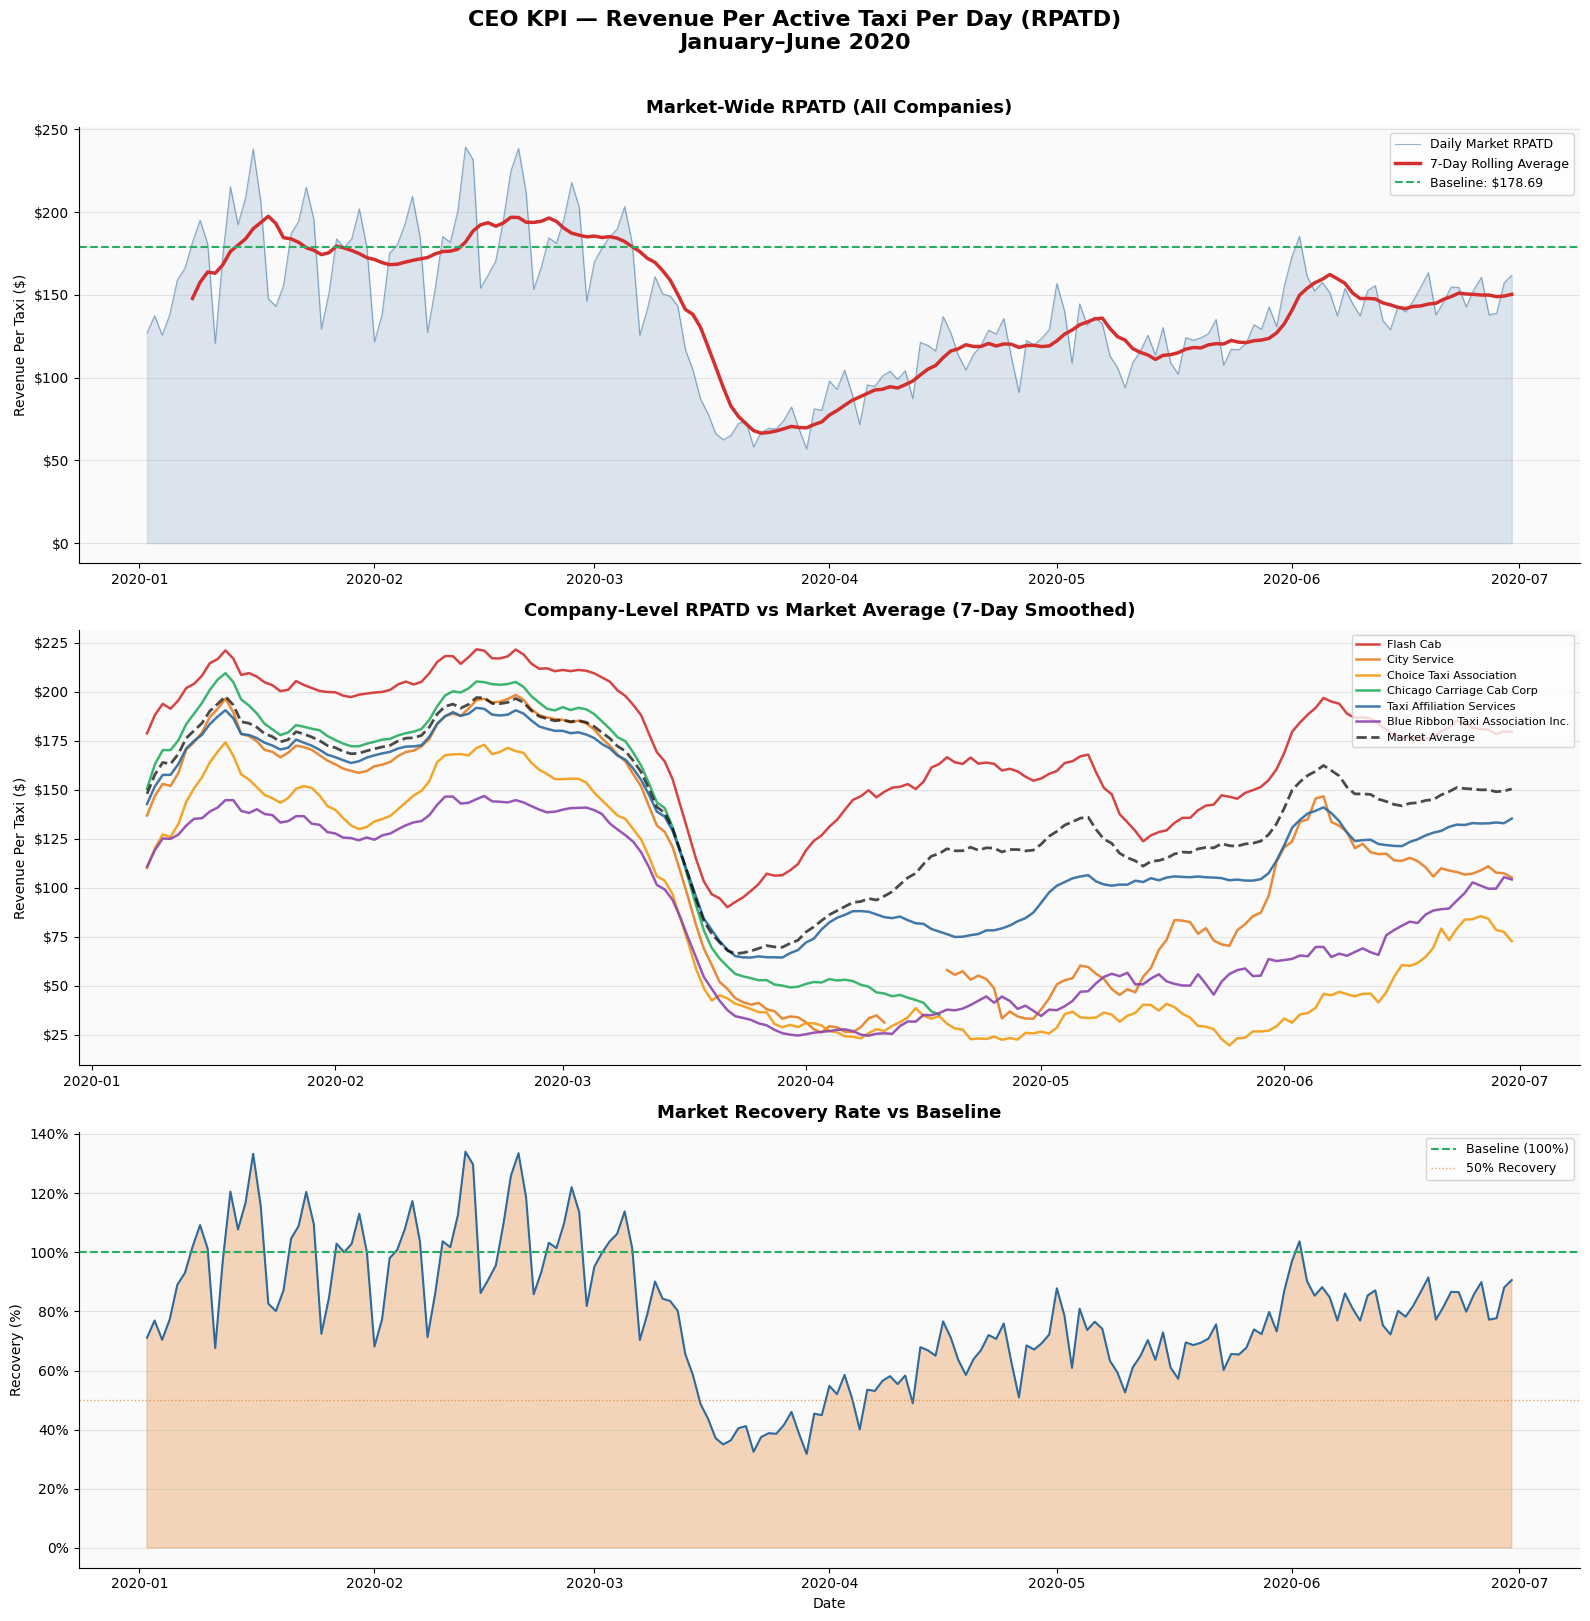

=== KEY KPI STATISTICS ===
baseline RPATD: $178.69

Lowest market RPATD: $56.86 on 2020-03-29
Highest market RPATD: $239.47 on 2020-02-13

Latest recovery rate: 90.6%

Company RPATD averages (Jan-Feb):
  Flash Cab: $204.81
  Chicago Carriage Cab Corp: $184.63
  Taxi Affiliation Services: $173.66
  City Service: $173.36
  Choice Taxi Association: $148.68
  Blue Ribbon Taxi Association Inc.: $134.04


In [29]:
# CEO KPI — Company-level RPATD + Market Benchmark

# Company level daily RPATD
company_daily = duckdb.query("""
    SELECT 
        DATE_TRUNC('day', trip_start_timestamp)::DATE as trip_date,
        company,
        COUNT(*) as total_trips,
        COUNT(DISTINCT taxi_id) as active_taxis,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(SUM(total_revenue) / COUNT(DISTINCT taxi_id), 2) as rpatd
    FROM df
    WHERE month != 7
    AND company IS NOT NULL
    GROUP BY DATE_TRUNC('day', trip_start_timestamp)::DATE, company
    ORDER BY trip_date, company
""").df()

company_daily['trip_date'] = pd.to_datetime(company_daily['trip_date'])

# Market level daily RPATD
market_daily = duckdb.query("""
    SELECT 
        DATE_TRUNC('day', trip_start_timestamp)::DATE as trip_date,
        COUNT(DISTINCT taxi_id) as active_taxis,
        ROUND(SUM(total_revenue), 2) as total_revenue,
        ROUND(SUM(total_revenue) / COUNT(DISTINCT taxi_id), 2) as market_rpatd
    FROM df
    WHERE month != 7
    GROUP BY DATE_TRUNC('day', trip_start_timestamp)::DATE
    ORDER BY trip_date
""").df()

# Filter out July after loading
company_daily = company_daily[company_daily['trip_date'] < '2020-07-01']
market_daily = market_daily[market_daily['trip_date'] < '2020-07-01']

print("Last date in company_daily:", company_daily['trip_date'].max())
print("Last date in market_daily:", market_daily['trip_date'].max())

market_daily['trip_date'] = pd.to_datetime(market_daily['trip_date'])

# 7-day rolling average for market
market_daily['market_rpatd_7day'] = market_daily['market_rpatd'].rolling(7).mean()

# baseline (Jan-Feb average)
baseline = market_daily[
    market_daily['trip_date'] < '2020-03-01'
]['market_rpatd'].mean()

# Recovery rate
market_daily['recovery_rate'] = (
    market_daily['market_rpatd'] / baseline * 100).round(1)

# Pivot company data for plotting
company_pivot = company_daily.pivot(
    index='trip_date', columns='company', values='rpatd')
company_pivot_smooth = company_pivot.rolling(7).mean()

# --- Charts ---
fig, axes = plt.subplots(3, 1, figsize=(16, 16))
fig.suptitle('CEO KPI — Revenue Per Active Taxi Per Day (RPATD)\n'
             'January–June 2020',
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Market RPATD with rolling average ---
axes[0].fill_between(market_daily['trip_date'],
                     market_daily['market_rpatd'],
                     alpha=0.15, color='#2d6a9f')
axes[0].plot(market_daily['trip_date'],
             market_daily['market_rpatd'],
             color='#2d6a9f', linewidth=0.8,
             alpha=0.5, label='Daily Market RPATD')
axes[0].plot(market_daily['trip_date'],
             market_daily['market_rpatd_7day'],
             color='#d32f2f', linewidth=2.5,
             label='7-Day Rolling Average')
axes[0].axhline(y=baseline, color='#27ae60',
                linewidth=1.5, linestyle='--',
                label=f'Baseline: ${baseline:.2f}')
axes[0].set_title('Market-Wide RPATD (All Companies)',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Revenue Per Taxi ($)', fontsize=10)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_facecolor('#fafafa')

# --- Chart 2: Company-level RPATD (7-day smoothed) ---
colors_companies = {
    'Flash Cab': '#d32f2f',
    'Taxi Affiliation Services': '#2d6a9f',
    'Chicago Carriage Cab Corp': '#27ae60',
    'City Service': '#e67e22',
    'Blue Ribbon Taxi Association Inc.': '#8e44ad',
    'Choice Taxi Association': '#f39c12'
}

for company_name in company_pivot_smooth.columns:
    color = colors_companies.get(company_name, '#95a5a6')
    axes[1].plot(company_pivot_smooth.index,
                 company_pivot_smooth[company_name],
                 color=color, linewidth=1.8,
                 label=company_name, alpha=0.9)

# Market average line
axes[1].plot(market_daily['trip_date'],
             market_daily['market_rpatd_7day'],
             color='black', linewidth=2,
             linestyle='--', label='Market Average',
             alpha=0.7)
axes[1].set_title('Company-Level RPATD vs Market Average (7-Day Smoothed)',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Revenue Per Taxi ($)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_facecolor('#fafafa')

# --- Chart 3: Recovery Rate ---
axes[2].fill_between(market_daily['trip_date'],
                     market_daily['recovery_rate'],
                     alpha=0.3,
                     color=market_daily['recovery_rate'].apply(
                         lambda x: '#d32f2f' if x < 50
                         else '#e67e22' if x < 80
                         else '#27ae60'))
axes[2].plot(market_daily['trip_date'],
             market_daily['recovery_rate'],
             color='#2d6a9f', linewidth=1.5)
axes[2].axhline(y=100, color='#27ae60',
                linewidth=1.5, linestyle='--',
                label='Baseline (100%)')
axes[2].axhline(y=50, color='#e67e22',
                linewidth=1, linestyle=':',
                label='50% Recovery', alpha=0.7)
axes[2].set_title('Market Recovery Rate vs Baseline',
                  fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Date', fontsize=10)
axes[2].set_ylabel('Recovery (%)', fontsize=10)
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('kpi_rpatd.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Key Statistics ---
print("=== KEY KPI STATISTICS ===")
print(f"baseline RPATD: ${baseline:.2f}")
print(f"\nLowest market RPATD: "
      f"${market_daily['market_rpatd'].min():.2f} on "
      f"{market_daily.loc[market_daily['market_rpatd'].idxmin(), 'trip_date'].date()}")
print(f"Highest market RPATD: "
      f"${market_daily['market_rpatd'].max():.2f} on "
      f"{market_daily.loc[market_daily['market_rpatd'].idxmax(), 'trip_date'].date()}")
print(f"\nLatest recovery rate: "
      f"{market_daily['recovery_rate'].iloc[-1]:.1f}%")

print(f"\nCompany RPATD averages (Jan-Feb):")
pre_covid = company_daily[
    company_daily['trip_date'] < '2020-03-01'
].groupby('company')['rpatd'].mean().sort_values(ascending=False)
for company_name, rpatd in pre_covid.items():
    print(f"  {company_name}: ${rpatd:.2f}")

In [30]:
# Check if July is still in company_daily and market_daily
print("Months in company_daily:")
print(sorted(company_daily['trip_date'].dt.month.unique()))

print("\nMonths in market_daily:")
print(sorted(market_daily['trip_date'].dt.month.unique()))

print("\nLast date in market_daily:")
print(market_daily['trip_date'].max())


Months in company_daily:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]

Months in market_daily:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]

Last date in market_daily:
2020-06-30 00:00:00


## CEO KPI — Revenue per Active Taxi per Day (RPATD)

### What the KPI Shows

Revenue Per Active Taxi Per Day (RPATD) measures how much revenue each working taxi generates on a daily basis. It provides a concise view of how efficiently the fleet converts demand into income.

The KPI can be calculated at two levels:

- **Company-level RPATD** — the primary metric for operational decision-making  
- **Market-level RPATD** — a benchmark for competitive positioning  

---

### Baseline Performance

**Pre-disruption baseline: $178.69 per active taxi per day**

This represents the normal level of daily productivity across the Chicago taxi market during January–February 2020.

---

### Key Findings

**1. A significant external demand shock caused a sharp decline in productivity**

RPATD dropped to a low of **$56.86 on March 29**, representing just **31.8% of the pre-disruption baseline**. This means each active taxi generated approximately **$121 less per day** compared to normal conditions.

Given that the dataset covers 2020, this decline likely reflects the impact of COVID-19 restrictions on urban mobility.

---

**2. Recovery was strong but incomplete**

By June 30th, RPATD recovered to **$161.96**, approximately **90.6% of the baseline level**. This indicates that demand rebounded relatively quickly, although fleet utilisation had not fully returned to pre-disruption levels.

---

**3. Company-level performance varies significantly**

Pre-disruption RPATD by company:

| Company | RPATD | vs Market |
|---|---|---|
| Flash Cab | $204.81 | +14.6% above market |
| Chicago Carriage Cab Corp | $184.63 | +3.3% above market |
| Taxi Affiliation Services | $173.66 | -2.8% below market |
| City Service | $173.36 | -3.0% below market |
| Choice Taxi Association | $148.68 | -16.8% below market |
| Blue Ribbon Taxi Association Inc. | $134.04 | -25.0% below market |

Flash Cab consistently outperformed the market by approximately 15%, suggesting more efficient fleet utilisation or a higher concentration of valuable trips.

In contrast, Blue Ribbon Taxi Association significantly underperformed despite having high revenue per mile, indicating lower trip frequency per taxi and underutilisation of the fleet.

---

### Why RPATD is the Right CEO KPI

RPATD is particularly valuable because each taxi incurs fixed daily costs such as insurance, licensing, and maintenance. This KPI shows whether the daily revenue generated per taxi is sufficient to cover these costs and contribute to profitability.

Unlike total revenue, which can increase simply by adding more taxis, RPATD controls for fleet size and provides a true measure of productivity and efficiency.

---

### Strategic Implications

A CEO monitoring RPATD daily can:

- Detect demand shocks quickly and respond proactively  
- Benchmark company performance against the market  
- Set clear productivity targets per taxi  
- Identify underutilised fleets or operational inefficiencies  
- Track recovery and growth using a single, meaningful metric  

The use of a 7-day rolling average further enhances the KPI by smoothing short-term fluctuations (e.g. weekday vs weekend variation) and revealing the underlying trend more clearly.

---

### Final Insight

Ultimately, RPATD translates complex operational performance into a single, actionable metric that supports daily decision-making at the executive level. It directly aligns with the goal of maximising profitability by focusing on both revenue generation and efficient use of resources.

## Section 6 — Tools, Approach & Alternatives

### Tools Used

| Tool | Purpose | Why Chosen |
|---|---|---|
| Python | Primary language | Industry standard for data analysis |
| pandas | Data loading and cleaning | Handles 465MB CSV efficiently, rich transformation API |
| DuckDB | Analytical queries | SQL syntax directly on pandas DataFrames — fast, readable, no database setup required |
| matplotlib | Charts | Full control over visualisation |
| seaborn | Heatmap | Clean statistical visualisation |
| Jupyter Notebook | Presentation format | Code, charts, and narrative in one document — ideal for MVP analysis |

### Why This Combination?

pandas and DuckDB complement each other perfectly:

- **pandas** excels at loading, cleaning, and transforming raw data
- **DuckDB** excels at analytical aggregations using familiar SQL syntax

Rather than choosing one or the other, combining both leverages the strengths 
of each. This mirrors how production data pipelines work — clean data in 
storage, SQL for analytical queries.

### Production Alternative — AWS Athena

In a production environment at Red Bull's scale, this analysis would be 
implemented differently:

1. Raw CSV stored as **Parquet files in AWS S3** — columnar format reduces 
   file size by ~80% and dramatically improves query performance
2. **AWS Athena** queries the data directly from S3 using standard SQL — 
   serverless, no infrastructure, approximately $0.02 for this dataset size
3. Results fed into a **Streamlit or QuickSight dashboard** for real-time 
   CEO monitoring

The SQL queries written with DuckDB in this notebook are directly portable 
to Athena — the same syntax works in both environments.

### Example Athena Query — Daily RPATD
```sql
SELECT 
    DATE_TRUNC('day', trip_start_timestamp) as trip_date,
    company,
    COUNT(DISTINCT taxi_id) as active_taxis,
    ROUND(SUM(total_revenue) / COUNT(DISTINCT taxi_id), 2) as rpatd
FROM chicago_taxi_2020
WHERE trip_start_timestamp < '2020-07-01'
GROUP BY 
    DATE_TRUNC('day', trip_start_timestamp),
    company
ORDER BY trip_date, company
```

### Other Approaches Considered

| Approach | Considered | Decision |
|---|---|---|
| Pure SQL / AWS Athena | Yes | Good for production scale — less visual for MVP presentation |
| Apache Spark | Yes | Overkill for 2M rows — designed for billions of rows |
| Google BigQuery | Yes | Valid alternative to Athena — same concept, different cloud |
| DuckDB only | Yes | Would require converting results to pandas for plotting anyway |
| Excel | No | Cannot handle 2 million rows |
| Streamlit dashboard | Planned | To be built as additional deliverable after notebook |

### Dataset Limitations

- Dataset covers **January 2 to June 30 2020** only — not a full year
- **No location data** — pickup/dropoff areas not available, limiting geographic analysis
- **Cash tips not captured** — cash gratuities paid directly to drivers are invisible
- **No driver shift data** — cannot calculate utilisation rate or hours worked
- **No cost data** — revenue analysis only, profitability cannot be calculated

These limitations were identified and handled transparently throughout the analysis.

## Section 5 — CEO KPI Design

### How KPIs Are Chosen

KPIs are not chosen based on available data. They are designed based on 
**business objectives** — what the company is trying to achieve. The data 
comes second.

As Adobe's KPI framework states:
> "KPIs must be selected so that they align with a company's strategy and 
> goals. All KPIs are metrics, but not all metrics are KPIs — KPIs are the 
> subset of metrics considered crucial for achieving strategic objectives."

The correct process is:
```
Step 1 → Define the business objective
Step 2 → Design the KPI that measures that objective  
Step 3 → Identify what data is needed
Step 4 → Collect or build that data
Step 5 → Calculate and monitor
```

---

### Step 1 — Business Objective

The core daily objective of a taxi company CEO is:

> **"Ensure each working taxi is generating enough revenue to cover its 
> costs and contribute to profit."**

This objective has three components:
- **Revenue** — is each taxi earning enough?
- **Productivity** — is each taxi completing enough trips?
- **Fleet efficiency** — are we deploying the right number of taxis?

---

### Step 2 — Ideal KPI: Daily Contribution Margin Per Active Taxi (DCMAT)

Designing from first principles, the ideal CEO daily KPI is 
**contribution margin per active taxi** — not revenue and not full 
profit margin.

**Why not full profit margin?**
Profit margin subtracts ALL costs including fixed costs like insurance, 
licensing, and salaries. Fixed costs don't change daily and can't be 
influenced operationally on a day-to-day basis. A CEO can't reduce 
insurance costs by Monday morning.

**Why not total revenue?**
Total revenue grows just by adding more taxis to the fleet. It doesn't 
measure whether each individual taxi is productive. A fleet of 3,000 
taxis earning $1 each looks better than a fleet of 100 taxis earning 
$100 each — but the second business is far more efficient.

**Why contribution margin?**
Contribution margin subtracts only **variable costs** — costs that change 
with each trip and can be influenced operationally:
- Driver commission (~45% of fare)
- Fuel cost per trip (~$2-3)
- Payment processing fees (~2.5% of card revenue)
- Dispatch fees
```
DCMAT = (Total Revenue − Variable Costs) / Active Taxis That Day
```

This tells the CEO: **"After paying the driver and covering direct trip 
costs, how much is each working taxi contributing to fixed cost coverage 
and profit?"**

If DCMAT drops below the daily fixed cost allocation per taxi — the 
business is losing money. That is the CEO's break-even signal.

---

### Step 3 — Data Limitation

This dataset contains **revenue data only**. There is no cost information:
- No driver commission rates
- No fuel costs
- No payment processing fees
- No dispatch fees

DCMAT **cannot be fully calculated** from this dataset alone.

In a production environment, cost data would be sourced from:
- Payroll and dispatch systems → driver commission
- Fleet management system → fuel costs per trip
- Payment provider API → processing fees
- These would be joined to trip data via taxi_id and trip_date

---

### Step 4 — Proxy KPI: Revenue Per Active Taxi Per Day (RPATD)

Since cost data is unavailable, **RPATD** serves as the strongest 
calculable proxy for DCMAT.
```
RPATD = Total Daily Revenue / Number of Taxis With ≥1 Trip That Day
```

**Why RPATD is a strong proxy:**
Variable costs are roughly proportional to revenue — higher revenue 
means more trips, more fuel, more commission. So RPATD and DCMAT move 
in the same direction. When RPATD drops, DCMAT drops. When RPATD 
recovers, DCMAT recovers.

**Why RPATD over simpler alternatives:**

| KPI | Problem |
|---|---|
| Total daily revenue | Grows just by adding taxis — doesn't measure productivity |
| Average fare per trip | Ignores how many trips each taxi completed |
| Total daily trips | Ignores revenue value — volume ≠ revenue |
| Fleet utilisation % | Requires shift data — not available in this dataset |
| **RPATD** | Controls for fleet size, measures genuine daily productivity |

---

### Step 5 — Leading vs Lagging

Following best practice KPI design, it is important to distinguish 
between leading and lagging indicators:

**RPATD is a lagging indicator** — it measures yesterday's performance. 
It tells the CEO what happened but not what will happen tomorrow.

**A complete CEO dashboard would pair RPATD with a leading indicator:**
- Advance booking rate → predicts tomorrow's demand
- Driver availability rate → predicts supply capacity
- Weather and events data → predicts demand spikes

> "Lagging indicators tell you about the outcome of past actions. 
> Leading indicators allow you to better predict if your product will 
> create the desired value in the future." — Roman Pichler

In a production system, the CEO dashboard would show:
- **RPATD (lagging)** — how did we perform yesterday?
- **Booking rate (leading)** — how will we perform tomorrow?

---

### KPI Implementation — What We Built

We calculated RPATD at two levels:

**Level 1 — Market-wide RPATD**
All companies combined — the industry benchmark.

**Level 2 — Company-level RPATD**
Each company individually — enables competitive benchmarking.

Both are enhanced with:
- **7-day rolling average** — smooths weekend/weekday volatility 
  to reveal the true underlying trend
- **Pre-COVID baseline** — January-February 2020 average ($178.69) 
  provides context for all subsequent values
- **Recovery rate** — expresses RPATD as a percentage of baseline, 
  giving the CEO an immediate sense of where the business stands 
  relative to normal

---

### Key Findings From The KPI

**Pre-COVID baseline: $178.69 per active taxi per day**

| Metric | Value | Date |
|---|---|---|
| Peak RPATD | $239.47 | February 13 |
| Lowest RPATD | $56.86 | March 29 |
| Recovery by June 30 | 90.6% of baseline | June 30 |

**Company performance (pre-COVID baseline):**

| Company | RPATD | vs Market |
|---|---|---|
| Flash Cab | $204.81 | +14.6% |
| Chicago Carriage Cab Corp | $184.63 | +3.3% |
| Taxi Affiliation Services | $173.66 | -2.8% |
| City Service | $173.36 | -3.0% |
| Choice Taxi Association | $148.68 | -16.8% |
| Blue Ribbon Taxi Association | $134.04 | -25.0% |

Flash Cab consistently outperformed the market by ~15% — suggesting 
more efficient fleet utilisation or higher-value trip selection.

---

### What This KPI Enables

A CEO monitoring RPATD daily can:
- **Detect demand shocks immediately** — COVID drop was visible 
  within days of lockdown
- **Benchmark competitively** — compare company RPATD against 
  market average
- **Set productivity targets** — "each taxi must generate ≥$150/day"
- **Track recovery** — single recovery rate number tells the 
  full story
- **Identify underperformers** — Blue Ribbon at $134 vs Flash Cab 
  at $205 signals an operational gap worth investigating

---

### Summary

> RPATD is the strongest CEO daily KPI calculable from this dataset. 
> It is a revenue-side proxy for the ideal metric — Daily Contribution 
> Margin Per Active Taxi. In a production system with full cost data, 
> RPATD would be enhanced with variable cost deductions to produce true 
> contribution margin. It would also be paired with a leading indicator 
> such as advance booking rate to give the CEO both backward-looking 
> performance measurement and forward-looking demand prediction.

In [31]:
# Final data verification — cross check all dashboard numbers

print("=== OVERVIEW PAGE ===")
print(f"Total trips: {len(df):,}")
print(f"Total revenue: ${df['total_revenue'].sum():,.0f}")
print(f"Avg revenue per trip: ${df['total_revenue'].mean():.2f}")
print(f"Avg trip miles: {df['trip_miles'].mean():.2f}")
print(f"Avg trip minutes: {df['trip_minutes'].mean():.1f}")
print(f"Unique taxis: {df['taxi_id'].nunique():,}")
print(f"Unique companies: {df['company'].nunique()}")

print("\n=== DEMAND PAGE ===")
peak_hour = df.groupby('hour')['unique_key'].count().idxmax()
peak_trips = df.groupby('hour')['unique_key'].count().max()
busiest_day = df.groupby('day_of_week')['unique_key'].count().idxmax()
print(f"Peak hour: {peak_hour}:00 with {peak_trips:,} trips")
print(f"Busiest day: {busiest_day}")

print("\n=== COMPANY PAGE ===")
company_check = df.groupby('company').agg(
    trips=('unique_key', 'count'),
    revenue=('total_revenue', 'sum'),
    avg_revenue=('total_revenue', 'mean')
).round(2).sort_values('revenue', ascending=False)
print(company_check)

print("\n=== PAYMENT PAGE ===")
payment_check = df.groupby('payment_type').agg(
    trips=('unique_key', 'count'),
    avg_revenue=('total_revenue', 'mean'),
    avg_tips=('tips', 'mean')
).round(2).sort_values('trips', ascending=False)
print(payment_check)

print("\n=== EFFICIENCY PAGE ===")
overall_rpm = df[df['trip_miles']>0]['total_revenue'].sum() / df[df['trip_miles']>0]['trip_miles'].sum()
overall_rpmn = df[df['trip_minutes']>0]['total_revenue'].sum() / df[df['trip_minutes']>0]['trip_minutes'].sum()
print(f"Revenue per mile: ${overall_rpm:.2f}")
print(f"Revenue per minute: ${overall_rpmn:.2f}")

print("\n=== KPI PAGE ===")
daily = df.groupby(df['trip_start_timestamp'].dt.date).agg(
    revenue=('total_revenue', 'sum'),
    active_taxis=('taxi_id', 'nunique')
)
daily['rpatd'] = daily['revenue'] / daily['active_taxis']
baseline = daily[daily.index < pd.Timestamp('2020-03-01').date()]['rpatd'].mean()
latest = daily[daily.index < pd.Timestamp('2020-07-01').date()]['rpatd'].iloc[-1]
print(f"Baseline RPATD: ${baseline:.2f}")
print(f"Lowest RPATD: ${daily['rpatd'].min():.2f} on {daily['rpatd'].idxmin()}")
print(f"Latest RPATD: ${latest:.2f}")
print(f"Recovery rate: {latest/baseline*100:.1f}%")


=== OVERVIEW PAGE ===
Total trips: 1,933,226
Total revenue: $30,591,868
Avg revenue per trip: $15.82
Avg trip miles: 3.32
Avg trip minutes: 13.4
Unique taxis: 2,716
Unique companies: 6

=== DEMAND PAGE ===
Peak hour: 17:00 with 143,664 trips
Busiest day: Thursday

=== COMPANY PAGE ===
                                    trips     revenue  avg_revenue
company                                                           
Taxi Affiliation Services          713185 11042275.00        15.48
Flash Cab                          545791  9179416.00        16.82
Chicago Carriage Cab Corp          273288  4461389.00        16.32
City Service                       196628  3173289.00        16.14
Blue Ribbon Taxi Association Inc.  121150  1414678.12        11.68
Choice Taxi Association             83184  1320823.12        15.88

=== PAYMENT PAGE ===
               trips  avg_revenue  avg_tips
payment_type                               
Cash          956134        12.27      0.00
Credit Card   816200    